In [1]:
import pandas as pd
import scanpy as sc
import plotnine as p9

import liana as li
import cell2cell as c2c
import decoupler as dc # needed for pathway enrichment

import warnings
warnings.filterwarnings('ignore')
from collections import defaultdict

%matplotlib inline

2026-06-11 15:56:51.604568: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-11 15:56:51.665254: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-11 15:56:53.995387: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
# NOTE: to use CPU instead of GPU, set use_gpu = False
use_gpu = True

if use_gpu:
    import torch
    import tensorly as tl

    device = "cuda" if torch.cuda.is_available() else "cpu"
    if device == "cuda":
        tl.set_backend('pytorch')
else:
    device = "cpu"

device

'cpu'

In [3]:
adata = sc.read_h5ad("clusters_annotated.h5ad")
adata

AnnData object with n_obs × n_vars = 37608 × 2706
    obs: 'sample_id', 'population', 'n_genes_by_counts', 'n_genes', 'percent_ribo', 'percent_mito', 'n_counts', 'leiden', 'Total Population', 'cell type'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Total Population_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'population_colors', 'rank_genes_groups', 'sample_id_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [4]:
raw_adata = sc.read_h5ad("raw_counts.h5ad")
raw_adata

AnnData object with n_obs × n_vars = 37608 × 15590
    obs: 'sample_id', 'population', 'n_genes_by_counts', 'n_genes', 'percent_ribo', 'percent_mito', 'n_counts'
    var: 'n_cells'
    uns: 'sample_id_colors'

In [5]:
## Add raw data info to clustering adata output
adata=adata.raw.to_adata()
adata

AnnData object with n_obs × n_vars = 37608 × 15590
    obs: 'sample_id', 'population', 'n_genes_by_counts', 'n_genes', 'percent_ribo', 'percent_mito', 'n_counts', 'leiden', 'Total Population', 'cell type'
    var: 'n_cells', 'percent_cells_expressing'
    uns: 'Total Population_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'population_colors', 'rank_genes_groups', 'sample_id_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    obsp: 'connectivities', 'distances'

In [6]:
adata.obs.head()

,sample_id,population,n_genes_by_counts,n_genes,percent_ribo,percent_mito,n_counts,leiden,Total Population,cell type
AAACCAGCAAAGTCTC-1,C1_GEX,adult,768,768,5.315402,0.000000,3123.0,0,Erythrocytes,Erythrocytes
AAACCAGCAGTAGCCC-1,C1_GEX,adult,540,540,10.983606,0.000000,1220.0,0,Erythrocytes,Erythrocytes
AAACCATTCGTACCTT-1,C1_GEX,adult,645,645,6.348282,0.000000,1717.0,0,Erythrocytes,Erythrocytes
AAACCATTCGTATACG-1,C1_GEX,adult,519,519,4.884792,0.184332,1085.0,0,Erythrocytes,Erythrocytes
AAACCCATCCACCATT-1,C1_GEX,adult,557,557,1.988376,0.000000,6538.0,0,Erythrocytes,Erythrocytes


In [7]:
adata.obs = adata.obs.drop(columns=['Total Population'])

In [8]:
adata.obs.head()

,sample_id,population,n_genes_by_counts,n_genes,percent_ribo,percent_mito,n_counts,leiden,cell type
AAACCAGCAAAGTCTC-1,C1_GEX,adult,768,768,5.315402,0.000000,3123.0,0,Erythrocytes
AAACCAGCAGTAGCCC-1,C1_GEX,adult,540,540,10.983606,0.000000,1220.0,0,Erythrocytes
AAACCATTCGTACCTT-1,C1_GEX,adult,645,645,6.348282,0.000000,1717.0,0,Erythrocytes
AAACCATTCGTATACG-1,C1_GEX,adult,519,519,4.884792,0.184332,1085.0,0,Erythrocytes
AAACCCATCCACCATT-1,C1_GEX,adult,557,557,1.988376,0.000000,6538.0,0,Erythrocytes


In [9]:
sample_key = 'sample_id'
condition_key = 'population'
groupby = 'cell type'

In [10]:
# filter cells and genes
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
# log1p normalize the data
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

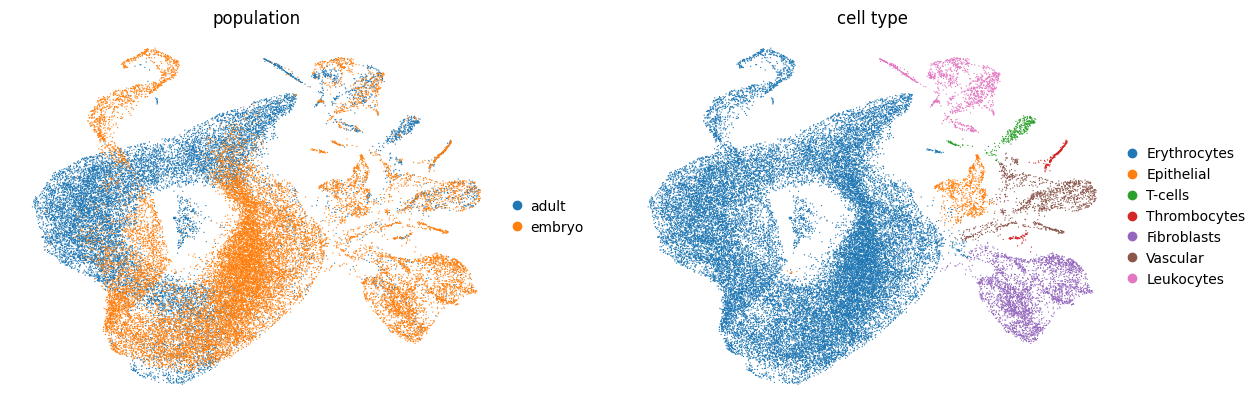

In [11]:
sc.pl.umap(adata, color=[condition_key, groupby], frameon=False)

In [12]:
### START LIANA

li.mt.show_methods()

# Select Resource (Default: Consensus)
resource = li.rs.select_resource('consensus')
resource

,ligand,receptor
0,LGALS9,PTPRC
1,LGALS9,MET
2,LGALS9,CD44
3,LGALS9,LRP1
4,LGALS9,CD47
...,...,...
4619,BMP2,ACTR2
4620,BMP15,ACTR2
4621,CSF1,CSF3R
4622,IL36G,IFNAR1


In [13]:
### LINK TO CHICKEN DATABASE
## download chicken homologs of human genes and perform Human-to-Chicken Ortholog Mapping

map_df = li.rs.get_hcop_orthologs(url='https://ftp.ebi.ac.uk/pub/databases/genenames/hcop/human_chicken_hcop_fifteen_column.txt.gz',
                                   columns=['human_symbol', 'chicken_symbol'],
                                   # NOTE: HCOP integrates multiple resource, so we can filter out mappings in at least 3 of them for confidence
                                   min_evidence=3
                                   )
# rename the columns to source and target, respectively for the original organism and the target organism

map_df = map_df.rename(columns={'human_symbol':'source', 'chicken_symbol':'target'})
map_df.tail()

# Translate Ligand-Receptor Database to Chicken Genes

chicken = li.rs.translate_resource(resource,
                                 map_df=map_df,
                                 columns=['ligand', 'receptor'],
                                 replace=True,
                                 # Here, we will be harsher and only keep mappings that don't map to more than 1 chicken gene
                                 one_to_many=1
                                 )

chicken

,ligand,receptor
14,NRG2,ERBB2_ERBB3
19,ADAM10,MET
20,ADAM10,IL6R
21,ADAM10,CD44
24,ADAM10,NOTCH1
...,...,...
4590,F8,LRP4
4605,CNTF,CRLF1
4607,NRG3,EGFR
4617,INHBA,ACTR2


In [14]:
li.mt.rank_aggregate.by_sample(
    adata,
    groupby=groupby,
    resource=chicken, # NOTE: uses human gene symbols!
    sample_key=sample_key, # sample key by which we which to loop
    use_raw=False, 
    verbose=True, # use 'full' to show all verbose information
    n_perms=None, # exclude permutations for speed
    return_all_lrs=True, # return all LR values
    )

Now running: E4_GEX: 100%|██████████| 6/6 [00:13<00:00,  2.29s/it]


In [15]:
## CHECK RESULTS 
adata.uns["liana_res"].sort_values("magnitude_rank").head(10)

,sample_id,source,target,ligand_complex,receptor_complex,lr_means,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,magnitude_rank
82614,E2_GEX,Thrombocytes,Thrombocytes,TLN1,ITGB3,0.673408,0.452141,5.814567,0.972111,0.349349,0.956020,3.336111e-08
112749,E3_GEX,Vascular,Leukocytes,APP,CD74,0.712519,0.359637,3.988649,1.037872,0.250515,0.951950,1.265822e-07
143619,E4_GEX,Vascular,Leukocytes,APP,CD74,0.635579,0.289590,3.655493,0.938083,0.233031,0.947383,1.317970e-07
82615,E2_GEX,Vascular,Leukocytes,APP,CD74,0.658464,0.319636,2.967399,0.965378,0.248164,0.948125,1.334390e-07
24745,C3_GEX,Fibroblasts,T-cells,COL1A1,CD44,0.725061,0.517019,4.948215,1.057042,0.433794,0.958578,1.436041e-07
112750,E3_GEX,Epithelial,Leukocytes,APP,CD74,0.705915,0.345144,3.948550,1.024655,0.240420,0.951001,2.847987e-07
143620,E4_GEX,Fibroblasts,Leukocytes,APP,CD74,0.633969,0.286454,3.644113,0.940663,0.230508,0.947110,2.965314e-07
82616,E2_GEX,Fibroblasts,Leukocytes,APP,CD74,0.643210,0.289249,2.880658,0.946564,0.224572,0.945612,3.002257e-07
0,C1_GEX,Fibroblasts,T-cells,COL1A1,CD44,0.681068,0.451494,9.066604,1.007431,0.361867,0.954978,4.245920e-07
112751,E3_GEX,Fibroblasts,Leukocytes,APP,CD74,0.696045,0.323484,3.888621,1.013064,0.225332,0.949468,5.062888e-07


In [16]:
tensor = li.multi.to_tensor_c2c(adata,
                                sample_key=sample_key,
                                score_key='magnitude_rank', # can be any score from liana
                                how='outer_cells' # how to join the samples
                                )

100%|██████████| 6/6 [00:09<00:00,  1.54s/it]


In [17]:
tensor.tensor.shape

(6, 468, 7, 7)

In [18]:
# save the tensor to disk, by using the c2c.io.export_variable_with_pickle function
c2c.io.export_variable_with_pickle(tensor, "tensor_total.pkl")

tensor_total.pkl  was correctly saved.


In [19]:
## BUILD METADATA
context_dict = adata.obs[[sample_key, condition_key]].drop_duplicates()
context_dict = dict(zip(context_dict[sample_key], context_dict[condition_key]))
context_dict = defaultdict(lambda: 'Unknown', context_dict)

tensor_meta = c2c.tensor.generate_tensor_metadata(interaction_tensor=tensor,
                                                  metadata_dicts=[context_dict, None, None, None],
                                                  fill_with_order_elements=True
                                                  )

In [20]:
tensor = c2c.analysis.run_tensor_cell2cell_pipeline(tensor,
                                                    tensor_meta,
                                                    copy_tensor=True, # Whether to output a new tensor or modifying the original
                                                    #rank=6, # Number of factors to perform the factorization. If None, it is automatically determined by an elbow analysis. Here, it was precomuputed.
                                                    tf_optimization='regular', # To define how robust we want the analysis to be. 
                                                    random_state=0, # Random seed for reproducibility
                                                    device=device, # Device to use. If using GPU and PyTorch, use 'cuda'. For CPU use 'cpu'
                                                    elbow_metric='error', # Metric to use in the elbow analysis.
                                                    smooth_elbow=False, # Whether smoothing the metric of the elbow analysis.
                                                    upper_rank=20, # Max number of factors to try in the elbow analysis
                                                    tf_init='random', # Initialization method of the tensor factorization
                                                    tf_svd='numpy_svd', # Type of SVD to use if the initialization is 'svd'
                                                    cmaps=None, # Color palettes to use in color each of the dimensions. Must be a list of palettes.
                                                    sample_col='Element', # Columns containing the elements in the tensor metadata
                                                    group_col='Category', # Columns containing the major groups in the tensor metadata
                                                    output_fig=False, # Whether to output the figures. If False, figures won't be saved a files if a folder was passed in output_folder.
                                                    )

Running Elbow Analysis


100%|██████████| 20/20 [12:14<00:00, 36.71s/it]


The rank at the elbow is: 7
Running Tensor Factorization


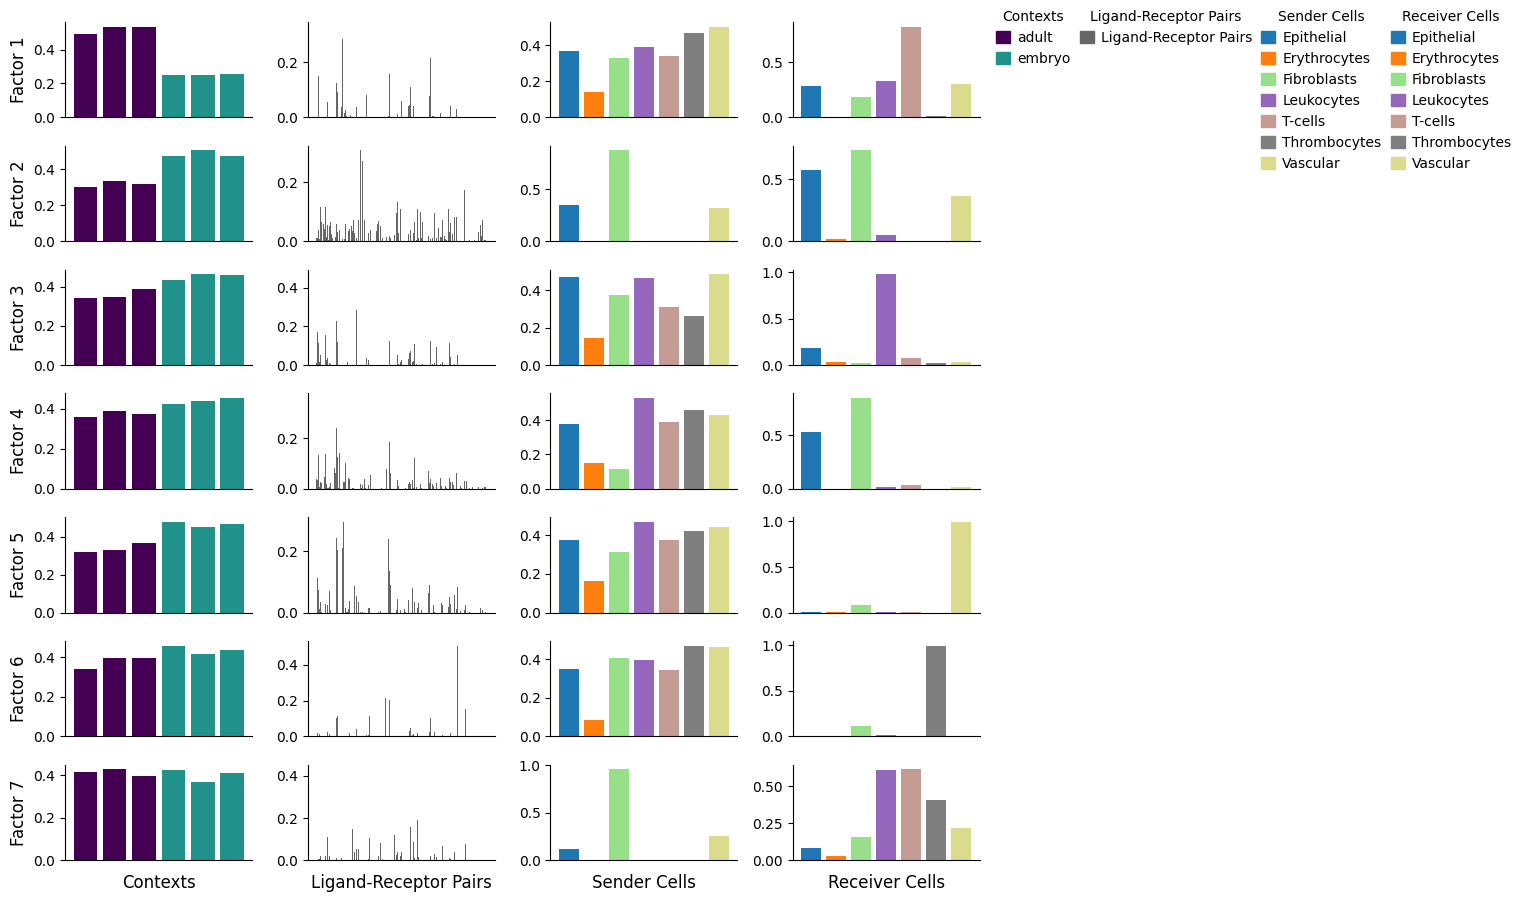

In [21]:
factors, axes = c2c.plotting.tensor_factors_plot(interaction_tensor=tensor,
                                                 metadata = tensor_meta, # This is the metadata for each dimension
                                                 sample_col='Element',
                                                 group_col='Category',
                                                 meta_cmaps = ['viridis', 'Dark2_r', 'tab20', 'tab20'],
                                                 fontsize=10, # Font size of the figures generated
                                                 )

In [22]:
factors = tensor.factors

In [23]:
factors.keys()

odict_keys(['Contexts', 'Ligand-Receptor Pairs', 'Sender Cells', 'Receiver Cells'])

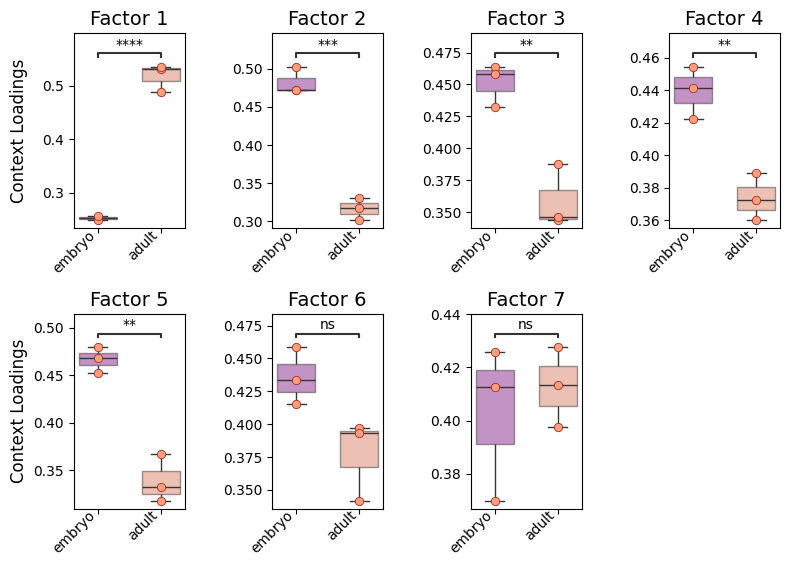

In [24]:
_ = c2c.plotting.context_boxplot(context_loadings=factors['Contexts'],
                                 metadict=context_dict,
                                 nrows=2,
                                 figsize=(8, 6),
                                 statistical_test='t-test_ind',
                                 pval_correction='fdr_bh',
                                 cmap='plasma',
                                 verbose=False,
                                )

(<Figure size 800x800 with 1 Axes>, <Axes: title={'center': 'Factor 1'}>)

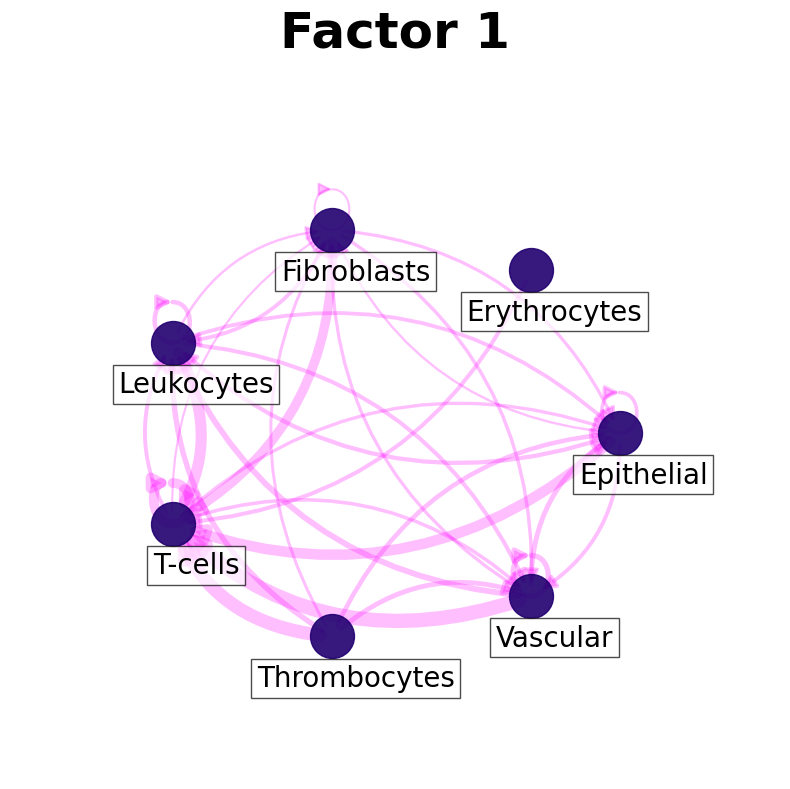

In [25]:
# generate the plot
c2c.plotting.ccc_networks_plot(factors,
                               included_factors=['Factor 1'],
                               network_layout='circular',
                               ccc_threshold=0.05, # Only important communication
                               nrows=1,
                               panel_size=(8, 8), # This changes the size of each figure panel.
                              )

(<Figure size 800x800 with 1 Axes>, <Axes: title={'center': 'Factor 2'}>)

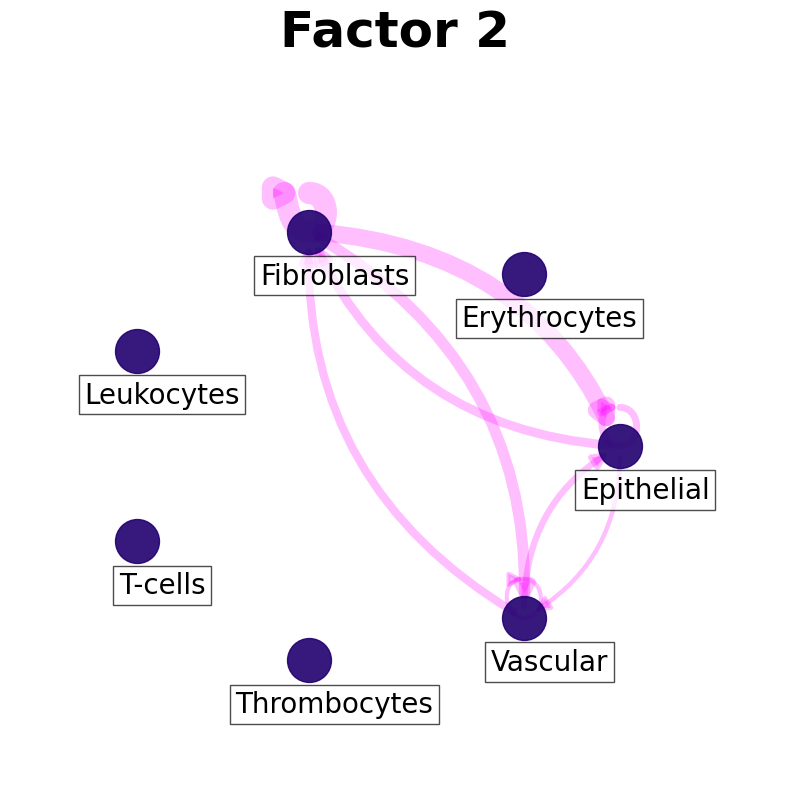

In [26]:
# generate the plot
c2c.plotting.ccc_networks_plot(factors,
                               included_factors=['Factor 2'],
                               network_layout='circular',
                               ccc_threshold=0.05, # Only important communication
                               nrows=1,
                               panel_size=(8, 8), # This changes the size of each figure panel.
                              )

(<Figure size 800x800 with 1 Axes>, <Axes: title={'center': 'Factor 3'}>)

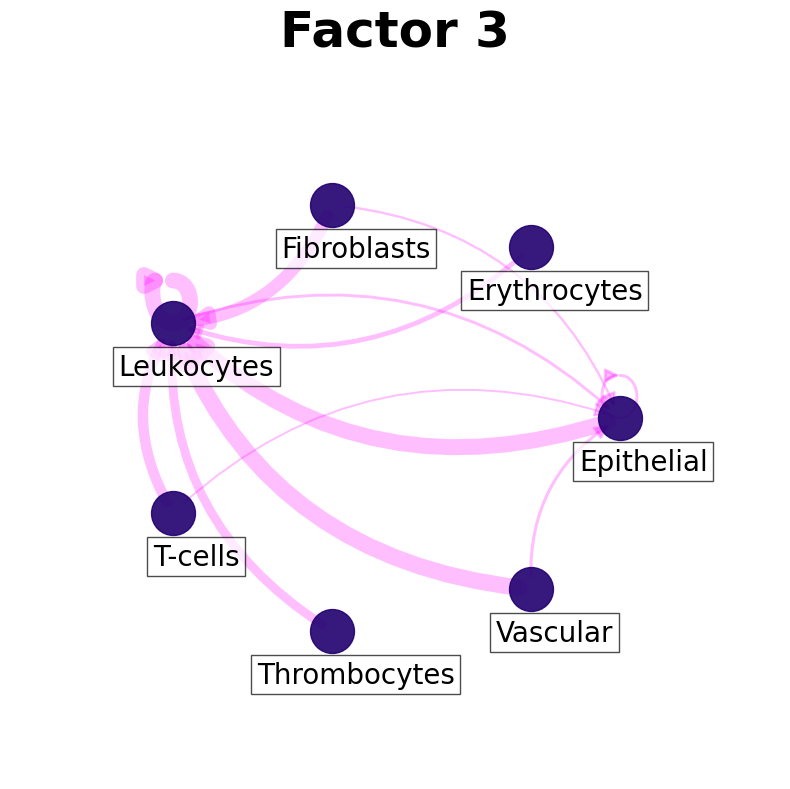

In [27]:
# generate the plot
c2c.plotting.ccc_networks_plot(factors,
                               included_factors=['Factor 3'],
                               network_layout='circular',
                               ccc_threshold=0.05, # Only important communication
                               nrows=1,
                               panel_size=(8, 8), # This changes the size of each figure panel.
                              )

(<Figure size 800x800 with 1 Axes>, <Axes: title={'center': 'Factor 4'}>)

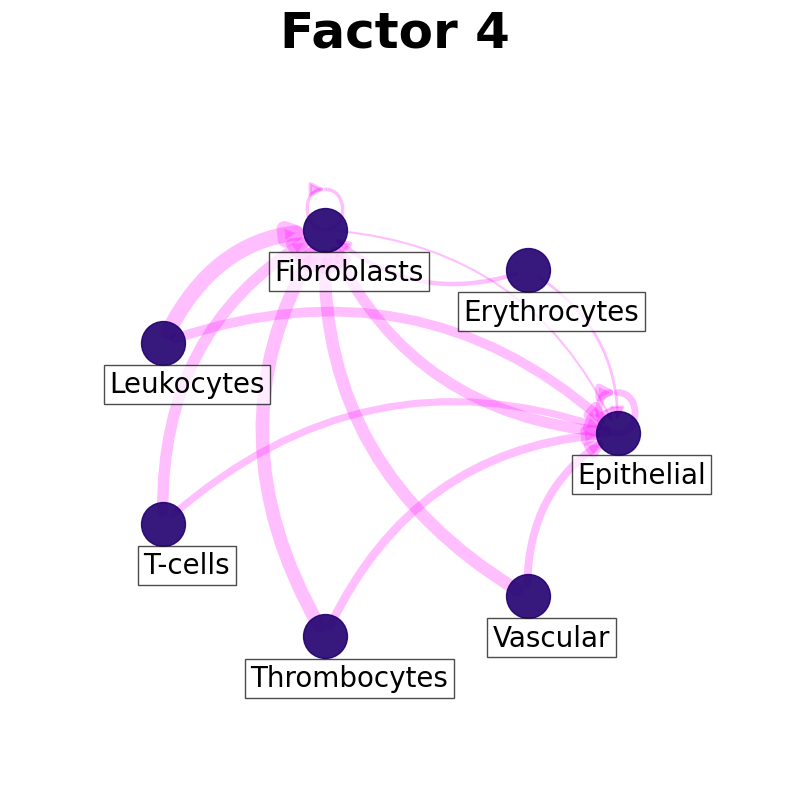

In [28]:
# generate the plot
c2c.plotting.ccc_networks_plot(factors,
                               included_factors=['Factor 4'],
                               network_layout='circular',
                               ccc_threshold=0.05, # Only important communication
                               nrows=1,
                               panel_size=(8, 8), # This changes the size of each figure panel.
                              )

(<Figure size 800x800 with 1 Axes>, <Axes: title={'center': 'Factor 5'}>)

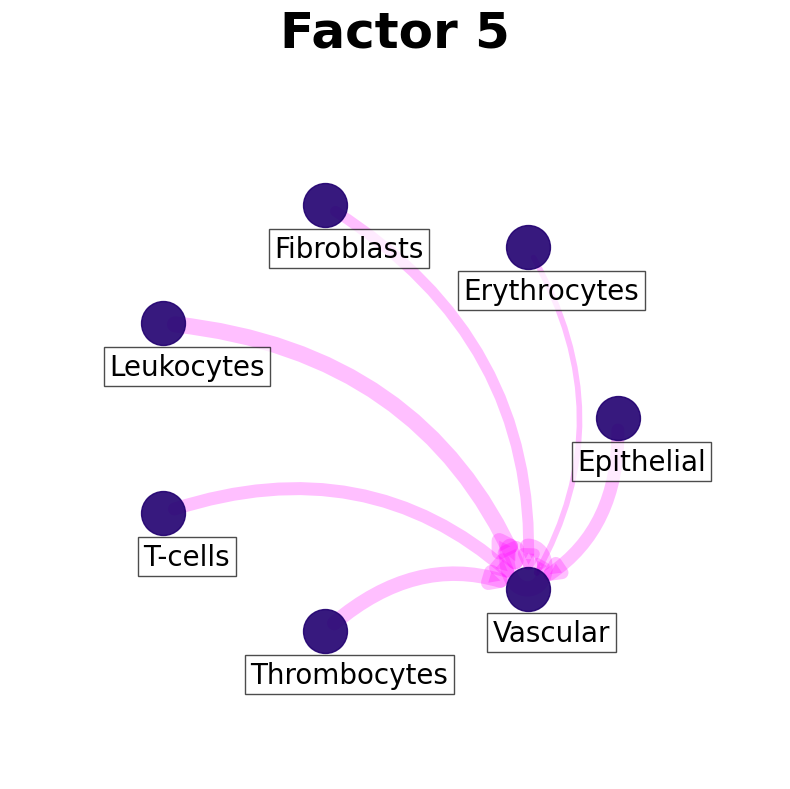

In [29]:
# generate the plot
c2c.plotting.ccc_networks_plot(factors,
                               included_factors=['Factor 5'],
                               network_layout='circular',
                               ccc_threshold=0.05, # Only important communication
                               nrows=1,
                               panel_size=(8, 8), # This changes the size of each figure panel.
                              )

In [30]:
lr_loadings = factors['Ligand-Receptor Pairs']
lr_loadings.sort_values("Factor 1", ascending=False).head(20)

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7
CALM1^KCNQ5,0.329996,4.564653e-02,7.882416e-09,2.742086e-01,9.194573e-02,3.229284e-02,2.631644e-03
TIMP3^CD44,0.323245,3.331029e-02,1.545418e-01,6.162784e-02,2.354479e-15,1.719241e-01,1.006650e-01
ADAM10^CD44,0.319311,3.758474e-03,1.381243e-01,4.985787e-02,7.191796e-13,1.358947e-01,9.555824e-03
CALM1^KCNQ1,0.285016,8.749477e-03,2.400918e-06,8.904830e-04,2.108746e-01,3.880939e-37,4.332335e-07
CALM1^PTPRA,0.282223,3.750822e-02,1.602746e-01,1.703587e-01,1.700579e-01,2.255283e-01,1.804535e-03
TIMP2^CD44,0.226528,4.484039e-02,8.236411e-02,2.556503e-02,8.920811e-13,9.245791e-02,1.871347e-01
PKLR^CD44,0.216887,7.152019e-03,1.218278e-01,4.022451e-02,2.348418e-11,1.010472e-01,2.117512e-02
YBX1^NOTCH1,0.204407,5.755922e-02,1.995404e-01,1.437686e-01,2.864350e-01,2.116038e-20,1.001697e-02
CALM1^FAS,0.203299,1.530127e-02,9.591573e-04,4.735139e-02,1.837454e-01,8.239130e-02,1.255758e-04
GNAI2^ADCY7,0.190154,5.648774e-07,1.073962e-01,7.408637e-07,5.225433e-02,8.054702e-45,4.961630e-07


In [31]:
lr_loadings = factors['Ligand-Receptor Pairs']
lr_loadings.sort_values("Factor 2", ascending=False).head(10)

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7
DCN^EGFR,8.546157e-07,0.308312,3.325523e-08,2.003300e-02,4.567562e-04,1.539625e-05,1.256219e-25
EFEMP1^EGFR,1.642887e-09,0.272346,4.255830e-07,1.533833e-02,1.205565e-03,3.135223e-07,3.222738e-26
VEGFA^EGFR,4.221970e-17,0.173251,8.664478e-09,3.048868e-02,9.290441e-03,3.826771e-11,2.406277e-31
SLIT2^APP,7.884665e-11,0.171398,1.934873e-03,1.564019e-15,1.666079e-02,1.296635e-10,1.368576e-01
DCN^MET,3.104728e-10,0.159382,7.935924e-05,1.896135e-02,7.052076e-50,8.280857e-18,5.283976e-46
MDK^SDC2,9.528687e-20,0.154104,2.882283e-14,7.794418e-09,3.276496e-02,7.750565e-03,2.612697e-02
ANOS1^SDC2,2.924349e-27,0.141679,1.738762e-16,3.634028e-30,1.660193e-02,4.416918e-03,2.832351e-02
TNC^EGFR,6.860171e-29,0.136672,4.040143e-19,1.873513e-14,4.094967e-05,3.297485e-15,2.112544e-27
LAMC1^DAG1,1.301615e-02,0.135455,7.067823e-02,5.750981e-02,5.982176e-02,5.151897e-29,3.331176e-02
HSPG2^DAG1,1.177486e-02,0.134327,5.182806e-02,3.589961e-02,4.369918e-02,1.016133e-30,3.646267e-02


In [32]:
lr_loadings = factors['Ligand-Receptor Pairs']
lr_loadings.sort_values("Factor 3", ascending=False).head(10)

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7
APP^CD74,6.043763e-02,0.006578,0.470447,2.915632e-10,8.881411e-02,6.559212e-02,1.036609e-01
COPA^CD74,3.907207e-02,0.009571,0.286142,6.156660e-09,5.437314e-02,4.244822e-02,5.163214e-02
C3^CD81,1.235189e-01,0.057977,0.228838,2.419732e-01,2.425983e-01,1.019317e-01,7.980571e-03
TLN1^ITGB5,7.325771e-10,0.012373,0.205817,9.237059e-02,1.024511e-01,1.756325e-02,8.626795e-07
YBX1^NOTCH1,2.044070e-01,0.057559,0.199540,1.437686e-01,2.864350e-01,2.116038e-20,1.001697e-02
ADAM10^IL6R,2.064783e-06,0.012129,0.172665,3.456092e-02,1.137709e-01,1.685737e-02,1.004948e-04
ADAM10^CADM1,3.744333e-04,0.002565,0.162864,2.673577e-02,8.946857e-43,4.182505e-81,1.461889e-07
CALM1^PTPRA,2.822226e-01,0.037508,0.160275,1.703587e-01,1.700579e-01,2.255283e-01,1.804535e-03
CALR^LRP1,4.520663e-10,0.079865,0.155603,1.696741e-01,4.775414e-02,1.848224e-15,1.008036e-02
APP^LRP1,2.298274e-11,0.117051,0.155066,1.384606e-01,2.936976e-02,1.957440e-20,1.823941e-02


In [33]:
lr_loadings = factors['Ligand-Receptor Pairs']
lr_loadings.sort_values("Factor 4", ascending=False).head(10)

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7
GNAI2^EGFR,2.522005e-05,7.168219e-02,1.314626e-05,0.360952,1.085364e-01,7.009836e-07,6.222290e-41
CALM1^KCNQ5,3.299961e-01,4.564653e-02,7.882416e-09,0.274209,9.194573e-02,3.229284e-02,2.631644e-03
C3^CD81,1.235189e-01,5.797696e-02,2.288375e-01,0.241973,2.425983e-01,1.019317e-01,7.980571e-03
TIMP3^MET,5.306602e-07,9.491027e-02,4.088255e-06,0.210707,1.580781e-32,4.467040e-18,5.732464e-50
CALM1^CACNA1C,1.815432e-21,3.565966e-02,3.338152e-29,0.205438,1.785733e-01,2.993445e-01,7.514750e-17
CALM1^INSR,2.073016e-02,5.198393e-02,1.549659e-01,0.191588,7.347176e-02,3.442267e-20,5.025782e-05
C3^LRP1,3.907262e-09,4.171394e-02,1.495423e-01,0.186549,5.514334e-02,8.660693e-14,5.686447e-06
PTPN6^EGFR,1.786953e-09,3.571487e-22,7.123814e-04,0.185471,5.021997e-02,1.112786e-13,1.708417e-81
GNAI2^IGF1R,1.593347e-01,1.611839e-02,1.242385e-01,0.184264,1.369094e-01,2.026575e-01,3.912183e-06
ADAM10^MET,2.939525e-05,4.803394e-02,2.494974e-03,0.180816,4.136322e-27,1.901519e-17,1.686185e-56


In [34]:
lr_loadings = factors['Ligand-Receptor Pairs']
lr_loadings.sort_values("Factor 5", ascending=False).head(10)

,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7
CALM1^PDE1C,0.001802,5.686831e-08,6.645452e-28,2.633503e-02,0.296119,1.239251e-03,4.941878e-34
YBX1^NOTCH1,0.204407,5.755922e-02,1.995404e-01,1.437686e-01,0.286435,2.116038e-20,1.001697e-02
GNAI2^CAV1,0.009475,1.403566e-09,3.290356e-22,2.376469e-02,0.244780,3.632955e-04,2.323562e-39
C3^CD81,0.123519,5.797696e-02,2.288375e-01,2.419732e-01,0.242598,1.019317e-01,7.980571e-03
GNAI2^EDNRB,0.003655,1.015270e-20,8.098163e-31,1.863824e-19,0.238315,3.132507e-07,4.584060e-38
GNAI2^ADCY8,0.000376,9.527801e-11,1.141497e-25,1.916063e-02,0.227876,1.158237e-03,7.333255e-37
CALM1^KCNQ1,0.285016,8.749477e-03,2.400918e-06,8.904830e-04,0.210875,3.880939e-37,4.332335e-07
C3^NRP1,0.091974,3.140249e-02,1.192049e-01,1.271616e-01,0.203225,1.163783e-01,1.623076e-04
CALM1^FAS,0.203299,1.530127e-02,9.591573e-04,4.735139e-02,0.183745,8.239130e-02,1.255758e-04
GNAI2^S1PR1,0.141710,4.800038e-05,2.559918e-07,3.225609e-02,0.180195,5.478005e-02,1.219712e-10


In [35]:
# load PROGENy pathways
net = dc.op.progeny(organism='human', top=5000)

In [36]:
# load full list of ligand-receptor pairs
lr_pairs = chicken

In [37]:
# generate ligand-receptor geneset
lr_progeny = li.rs.generate_lr_geneset(lr_pairs, net, lr_sep="^").rename(columns = {"interaction": "target"})
lr_progeny.head()

,source,target,weight
18,EGFR,ADAM10^NOTCH1,-0.924934
22,MAPK,ADAM10^NOTCH1,-0.925038
35,MAPK,ADAM10^TSPAN10,-1.021208
46,VEGF,TNFSF11^TNFRSF11A,2.571622
172,PI3K,APP^ADRA2A,-2.040150


In [38]:
# run enrichment analysis
estimate, pvals = dc.mt.ulm(lr_loadings.transpose(), lr_progeny, raw=False)

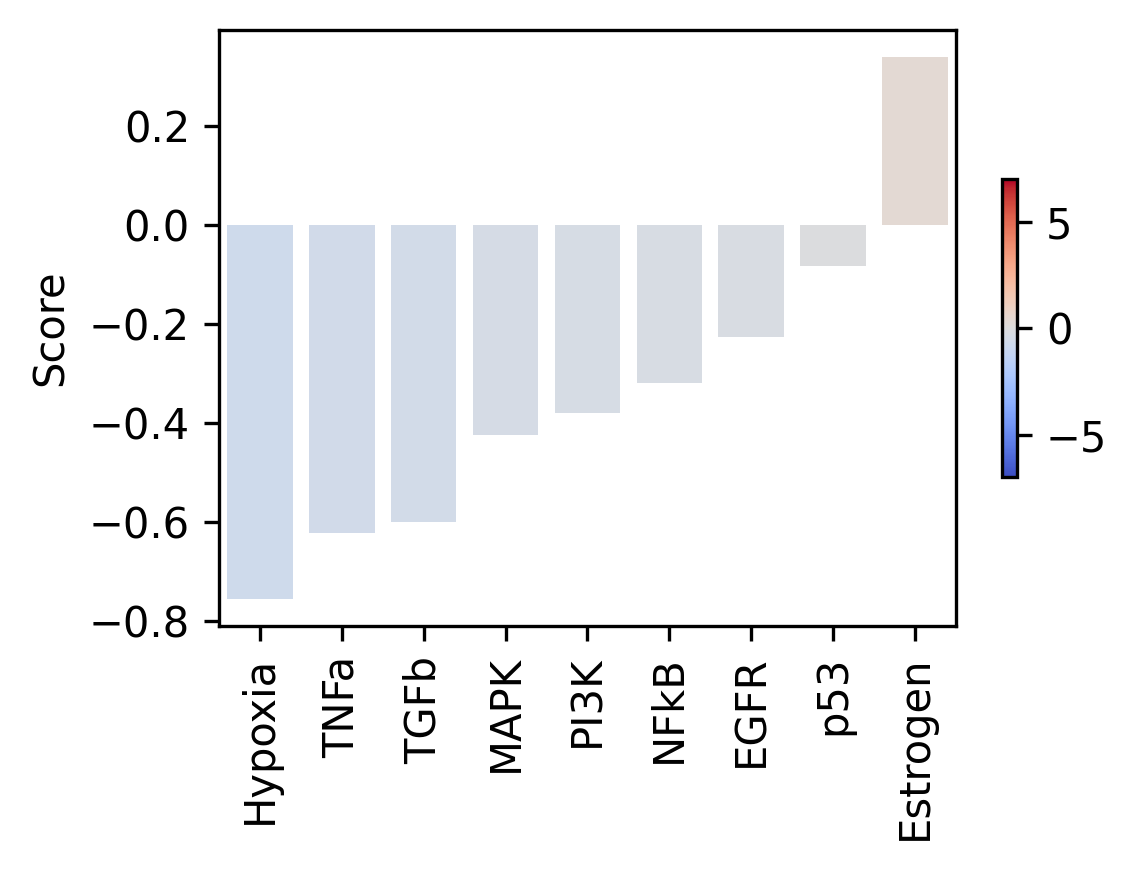

In [39]:
dc.pl.barplot(estimate, 'Factor 1', vertical=True, cmap='coolwarm', vmin=-7, vmax=7, dpi=300, save='figures/factor_1-enrichment.png')

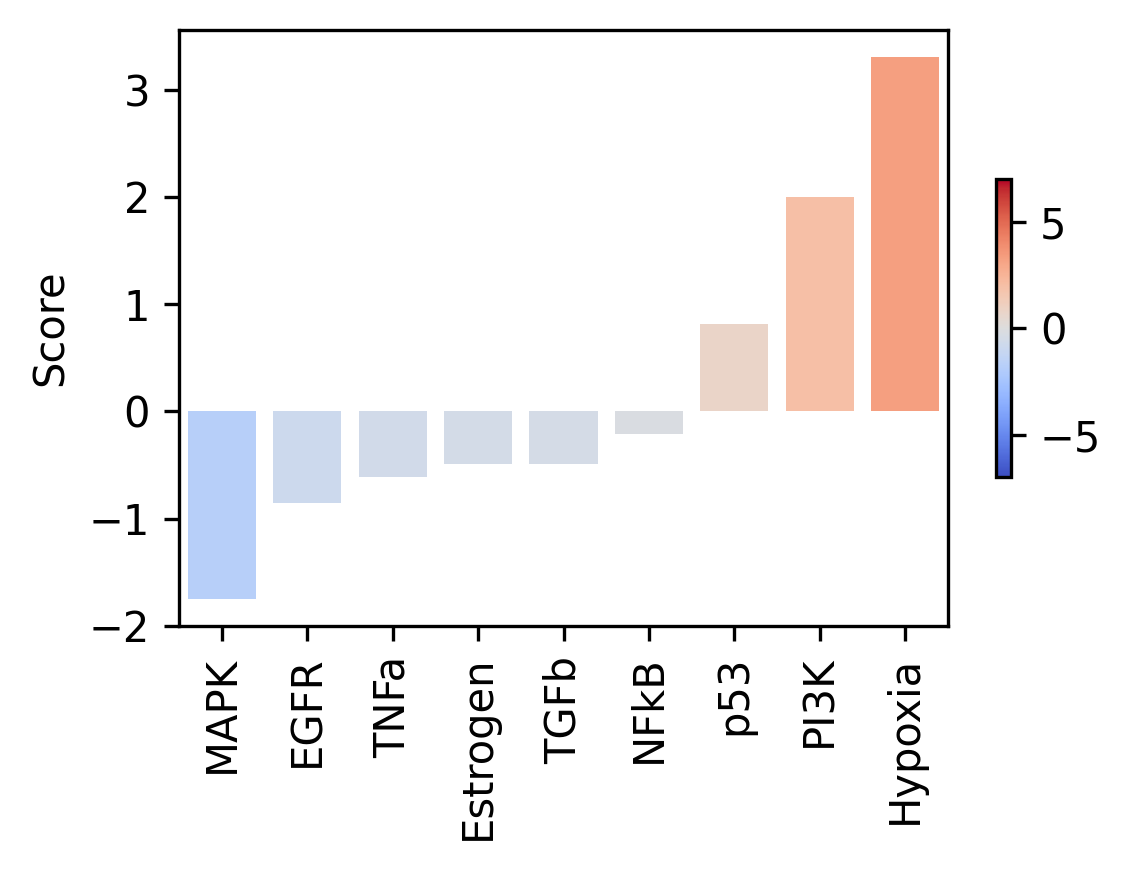

In [40]:
dc.pl.barplot(estimate, 'Factor 2', vertical=True, cmap='coolwarm', vmin=-7, vmax=7, dpi=300, save='figures/factor_2-enrichment.png')

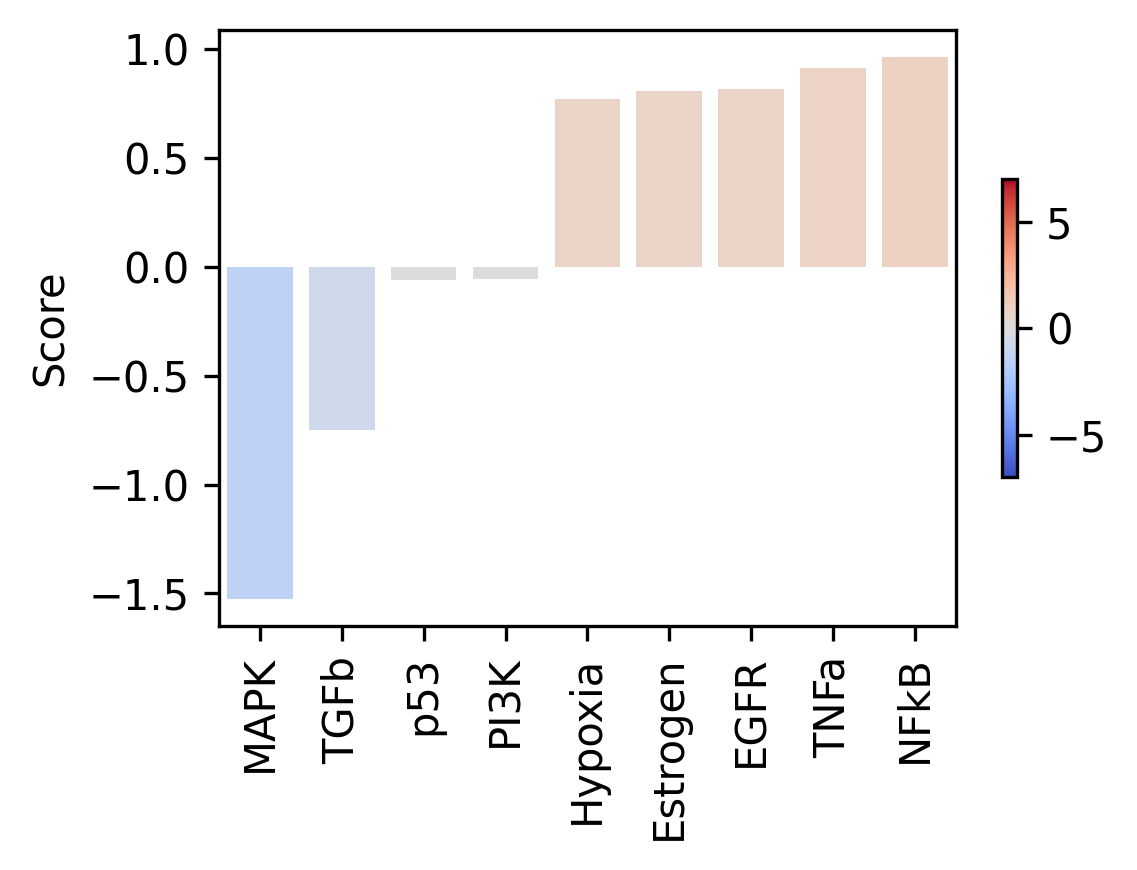

In [41]:
dc.pl.barplot(estimate, 'Factor 3', vertical=True, cmap='coolwarm', vmin=-7, vmax=7, dpi=300, save='figures/factor_3-enrichment.png')

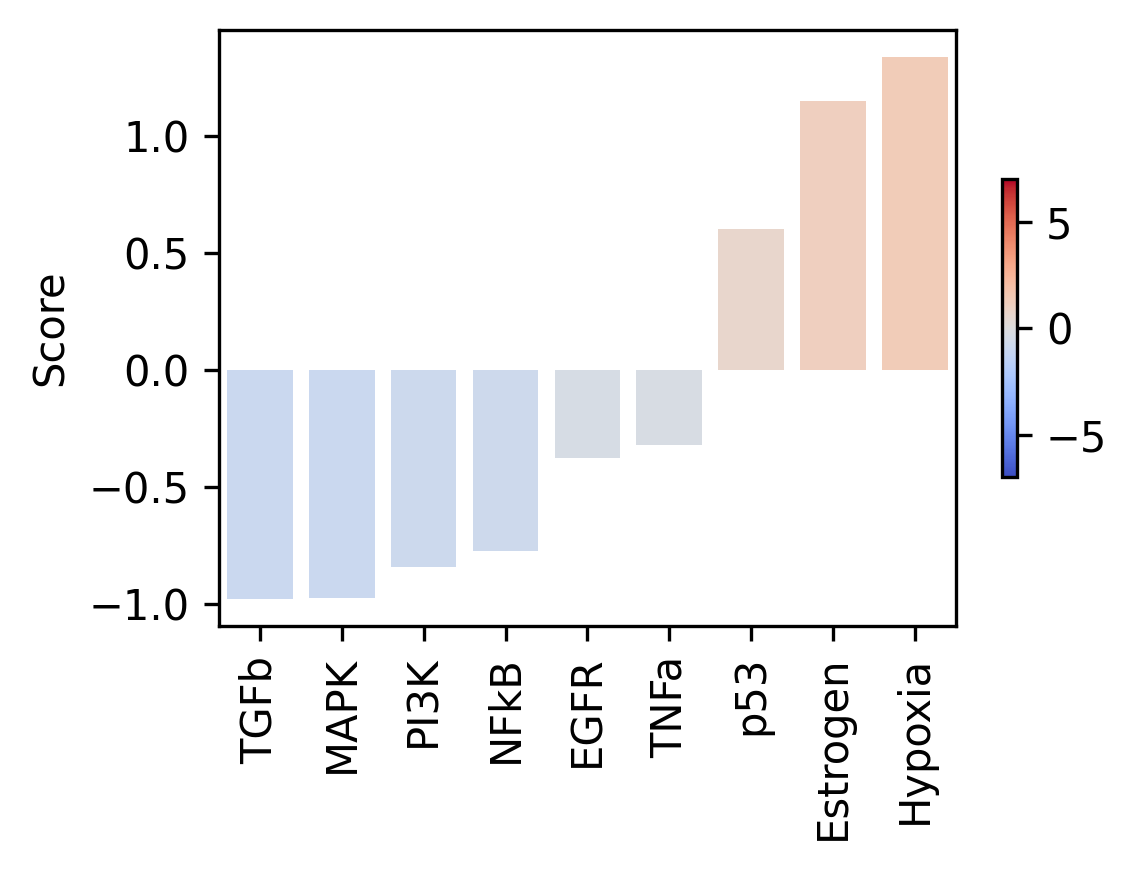

In [42]:
dc.pl.barplot(estimate, 'Factor 4', vertical=True, cmap='coolwarm', vmin=-7, vmax=7, dpi=300, save='figures/factor_4-enrichment.png')

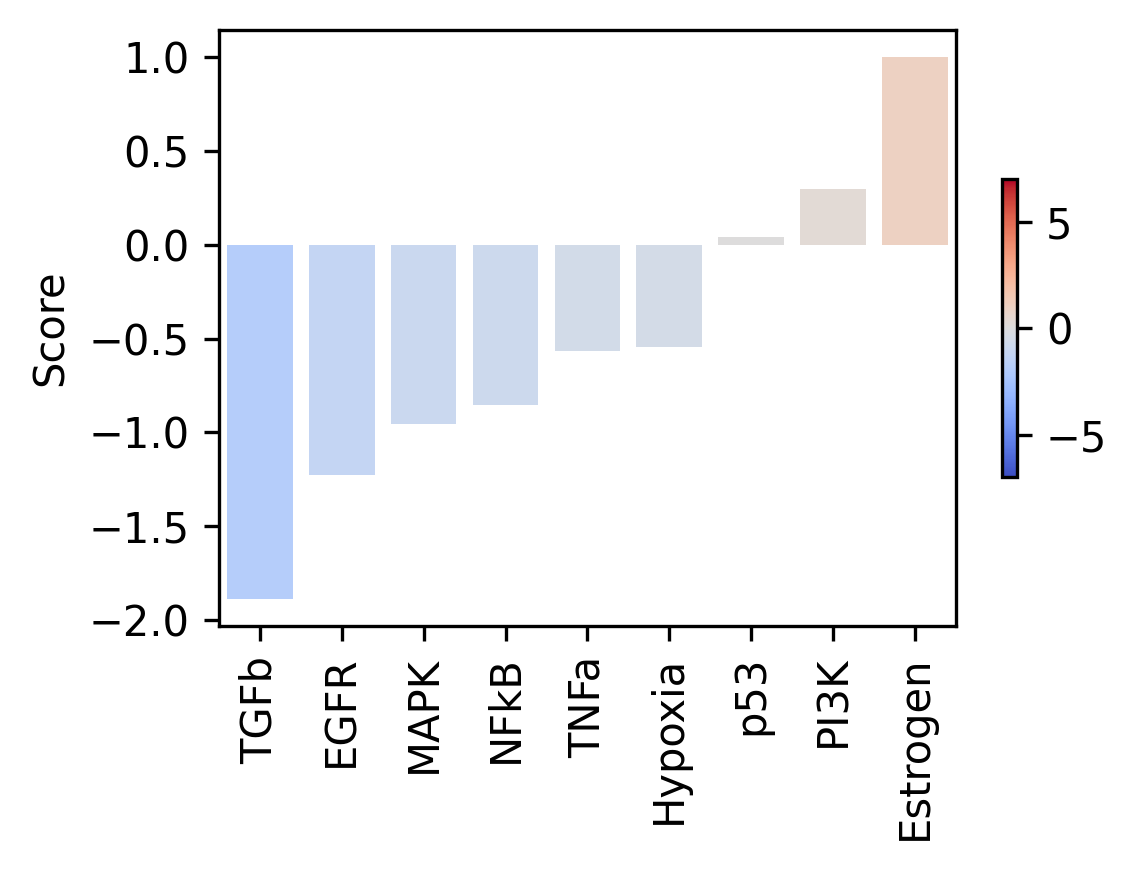

In [43]:
dc.pl.barplot(estimate, 'Factor 5', vertical=True, cmap='coolwarm', vmin=-7, vmax=7, dpi=300, save='figures/factor_5-enrichment.png')

In [44]:
selected_factor = 'Factor 1'

In [45]:
loading_product = c2c.analysis.tensor_downstream.get_joint_loadings(factors,
                                                                    dim1='Sender Cells',
                                                                    dim2='Receiver Cells',
                                                                    factor=selected_factor,
                                                                   )

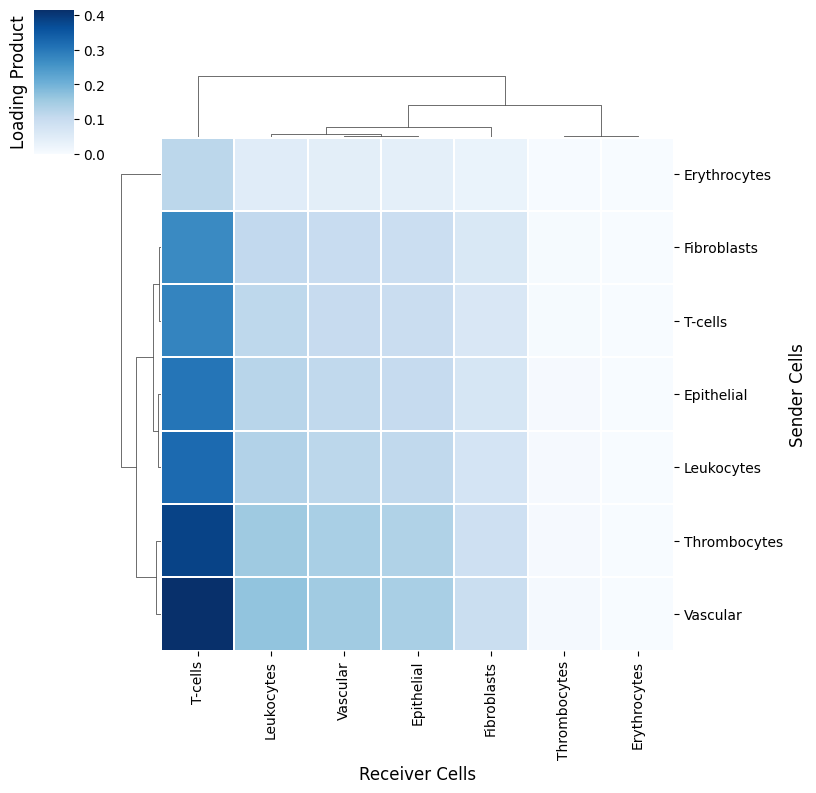

In [46]:
lprod_cm = c2c.plotting.loading_clustermap(loading_product.T, # Remove .T to transpose the axes
                                           use_zscore=False, # Whether standardizing the loadings across factors
                                           figsize=(8, 8),
                                           filename='figures/Clustermap-CC-Pairs_factor_1.pdf',
                                           cbar_label='Loading Product',
                                          )

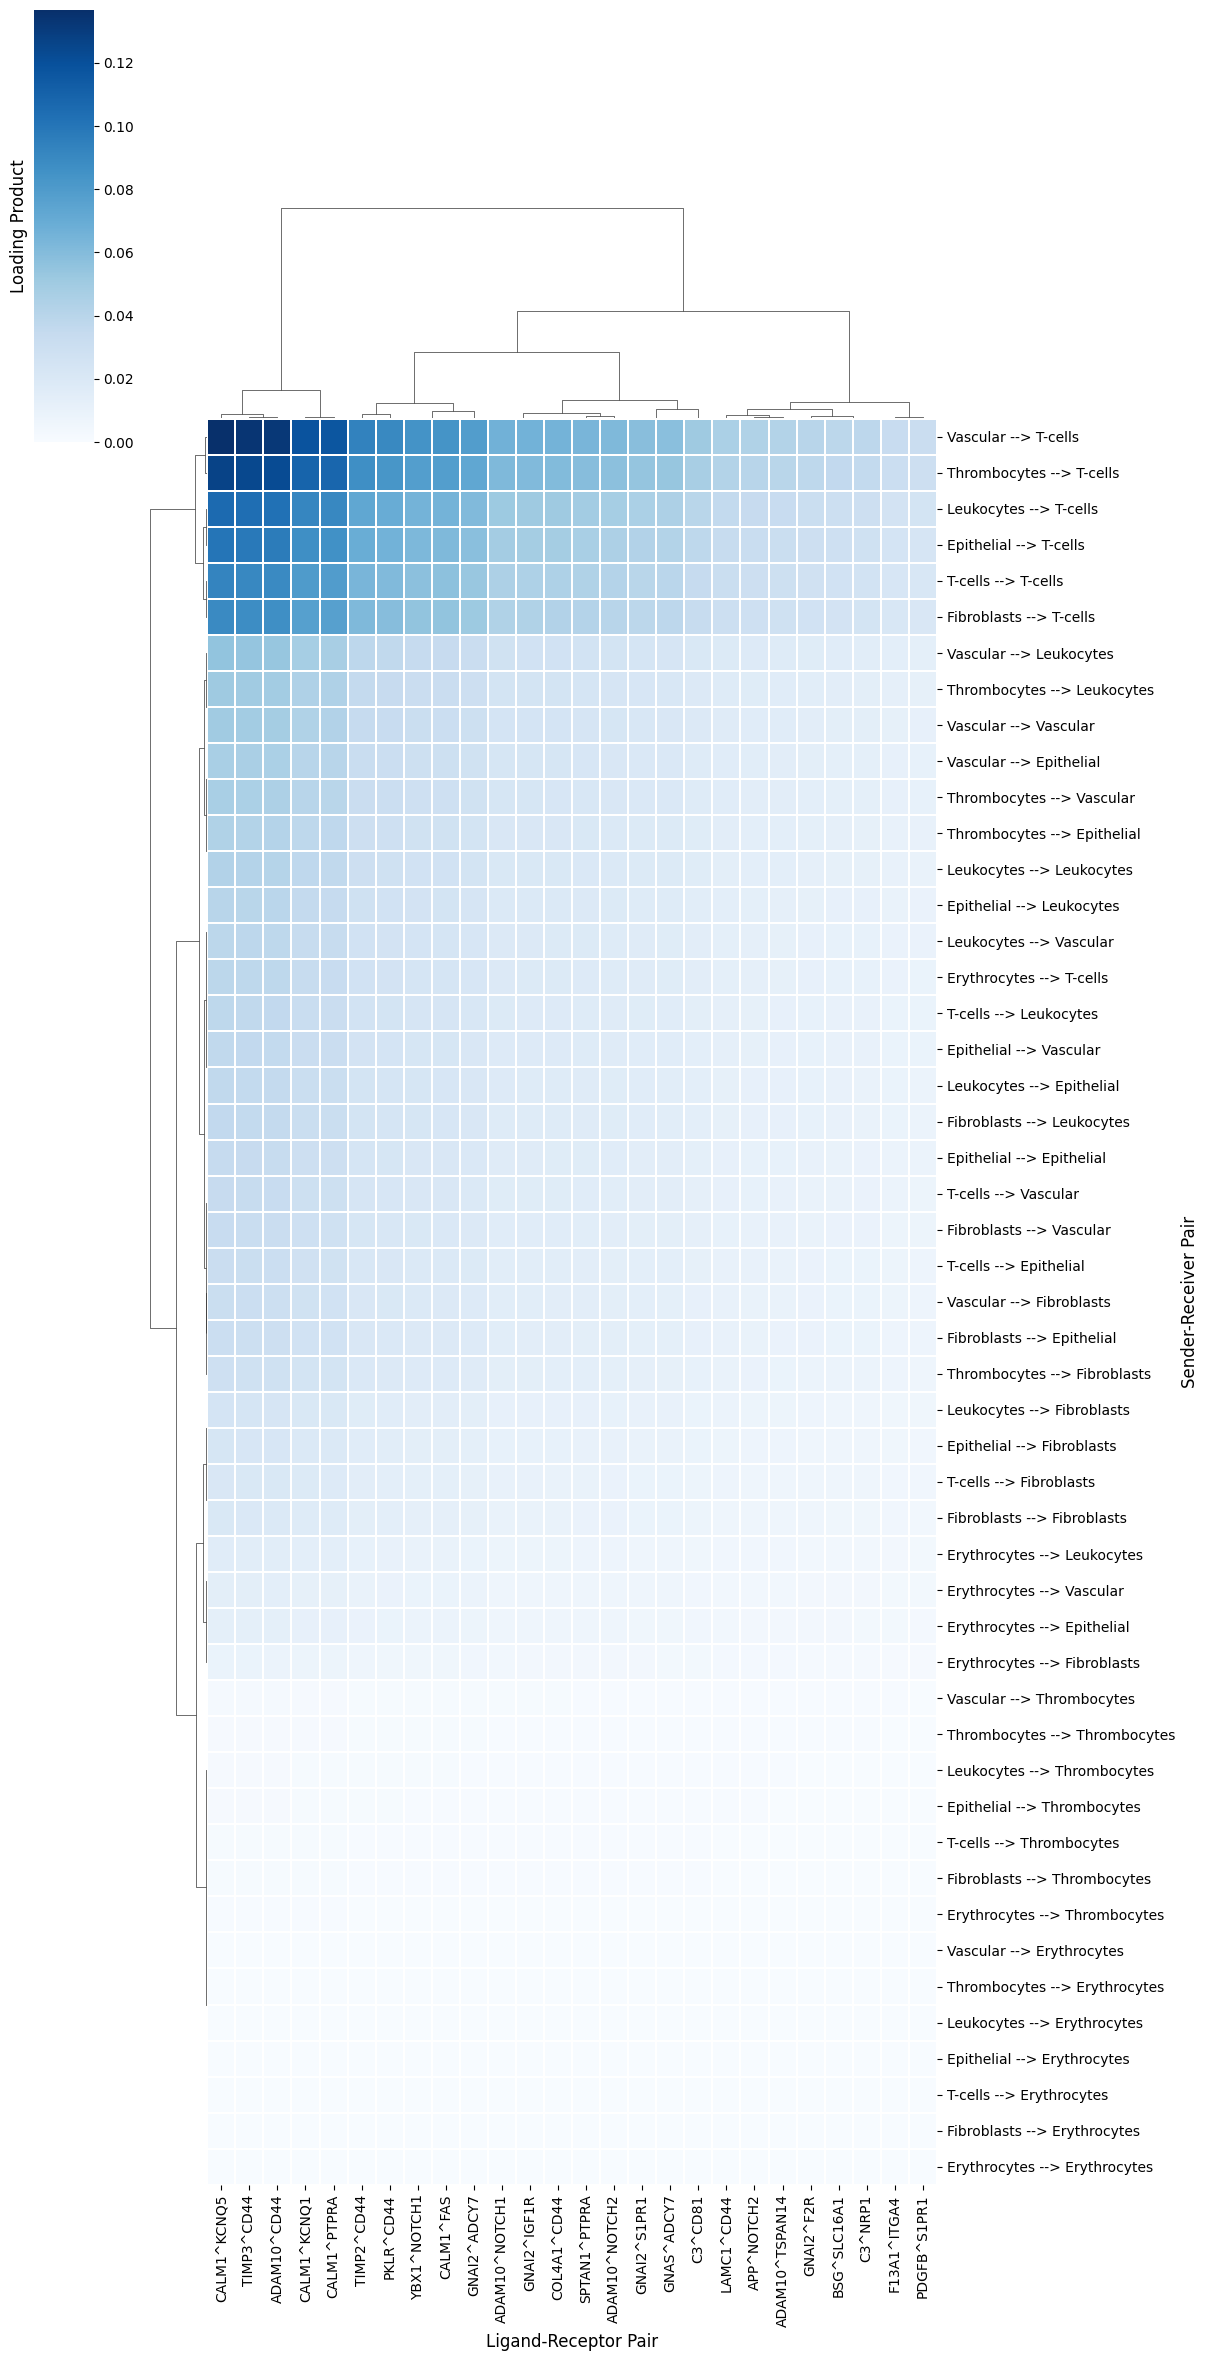

In [47]:
lr_cell_product = c2c.analysis.tensor_downstream.get_lr_by_cell_pairs(factors,
                                                                      lr_label='Ligand-Receptor Pairs',
                                                                      sender_label='Sender Cells',
                                                                      receiver_label='Receiver Cells',
                                                                      order_cells_by='receivers',
                                                                      factor=selected_factor,
                                                                      cci_threshold=None, # None for considering all cell-cell pairs.
                                                                      lr_threshold=0.075 # Prioritize important pairs. None for considering all of them
                                                                     )

lsr_prod_cm = c2c.plotting.loading_clustermap(lr_cell_product,
                                              use_zscore=False, # Whether standardizing the loadings across factors
                                              figsize=(12, 24),
                                              filename='figures/Clustermap-LR-CC-Pairs_factor_1.pdf',
                                              cbar_label='Loading Product',
                                              yticklabels=1
                                             )

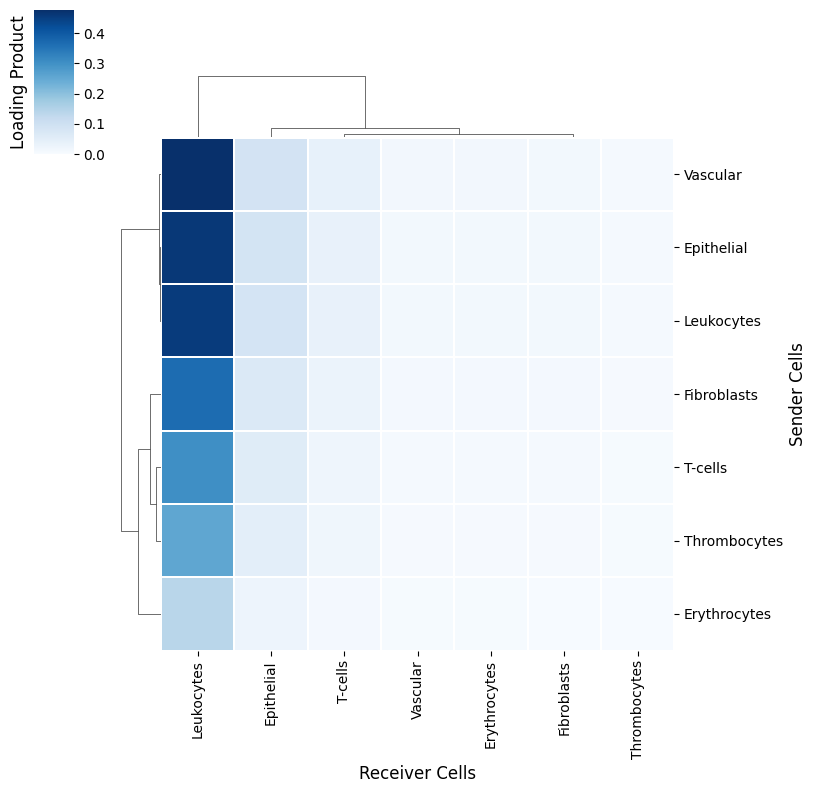

In [48]:
selected_factor = 'Factor 3'

loading_product = c2c.analysis.tensor_downstream.get_joint_loadings(factors,
                                                                    dim1='Sender Cells',
                                                                    dim2='Receiver Cells',
                                                                    factor=selected_factor,
                                                                   )

lprod_cm = c2c.plotting.loading_clustermap(loading_product.T, # Remove .T to transpose the axes
                                           use_zscore=False, # Whether standardizing the loadings across factors
                                           figsize=(8, 8),
                                           filename='figures/Clustermap-CC-Pairs_factor_3.pdf',
                                           cbar_label='Loading Product',
                                          )

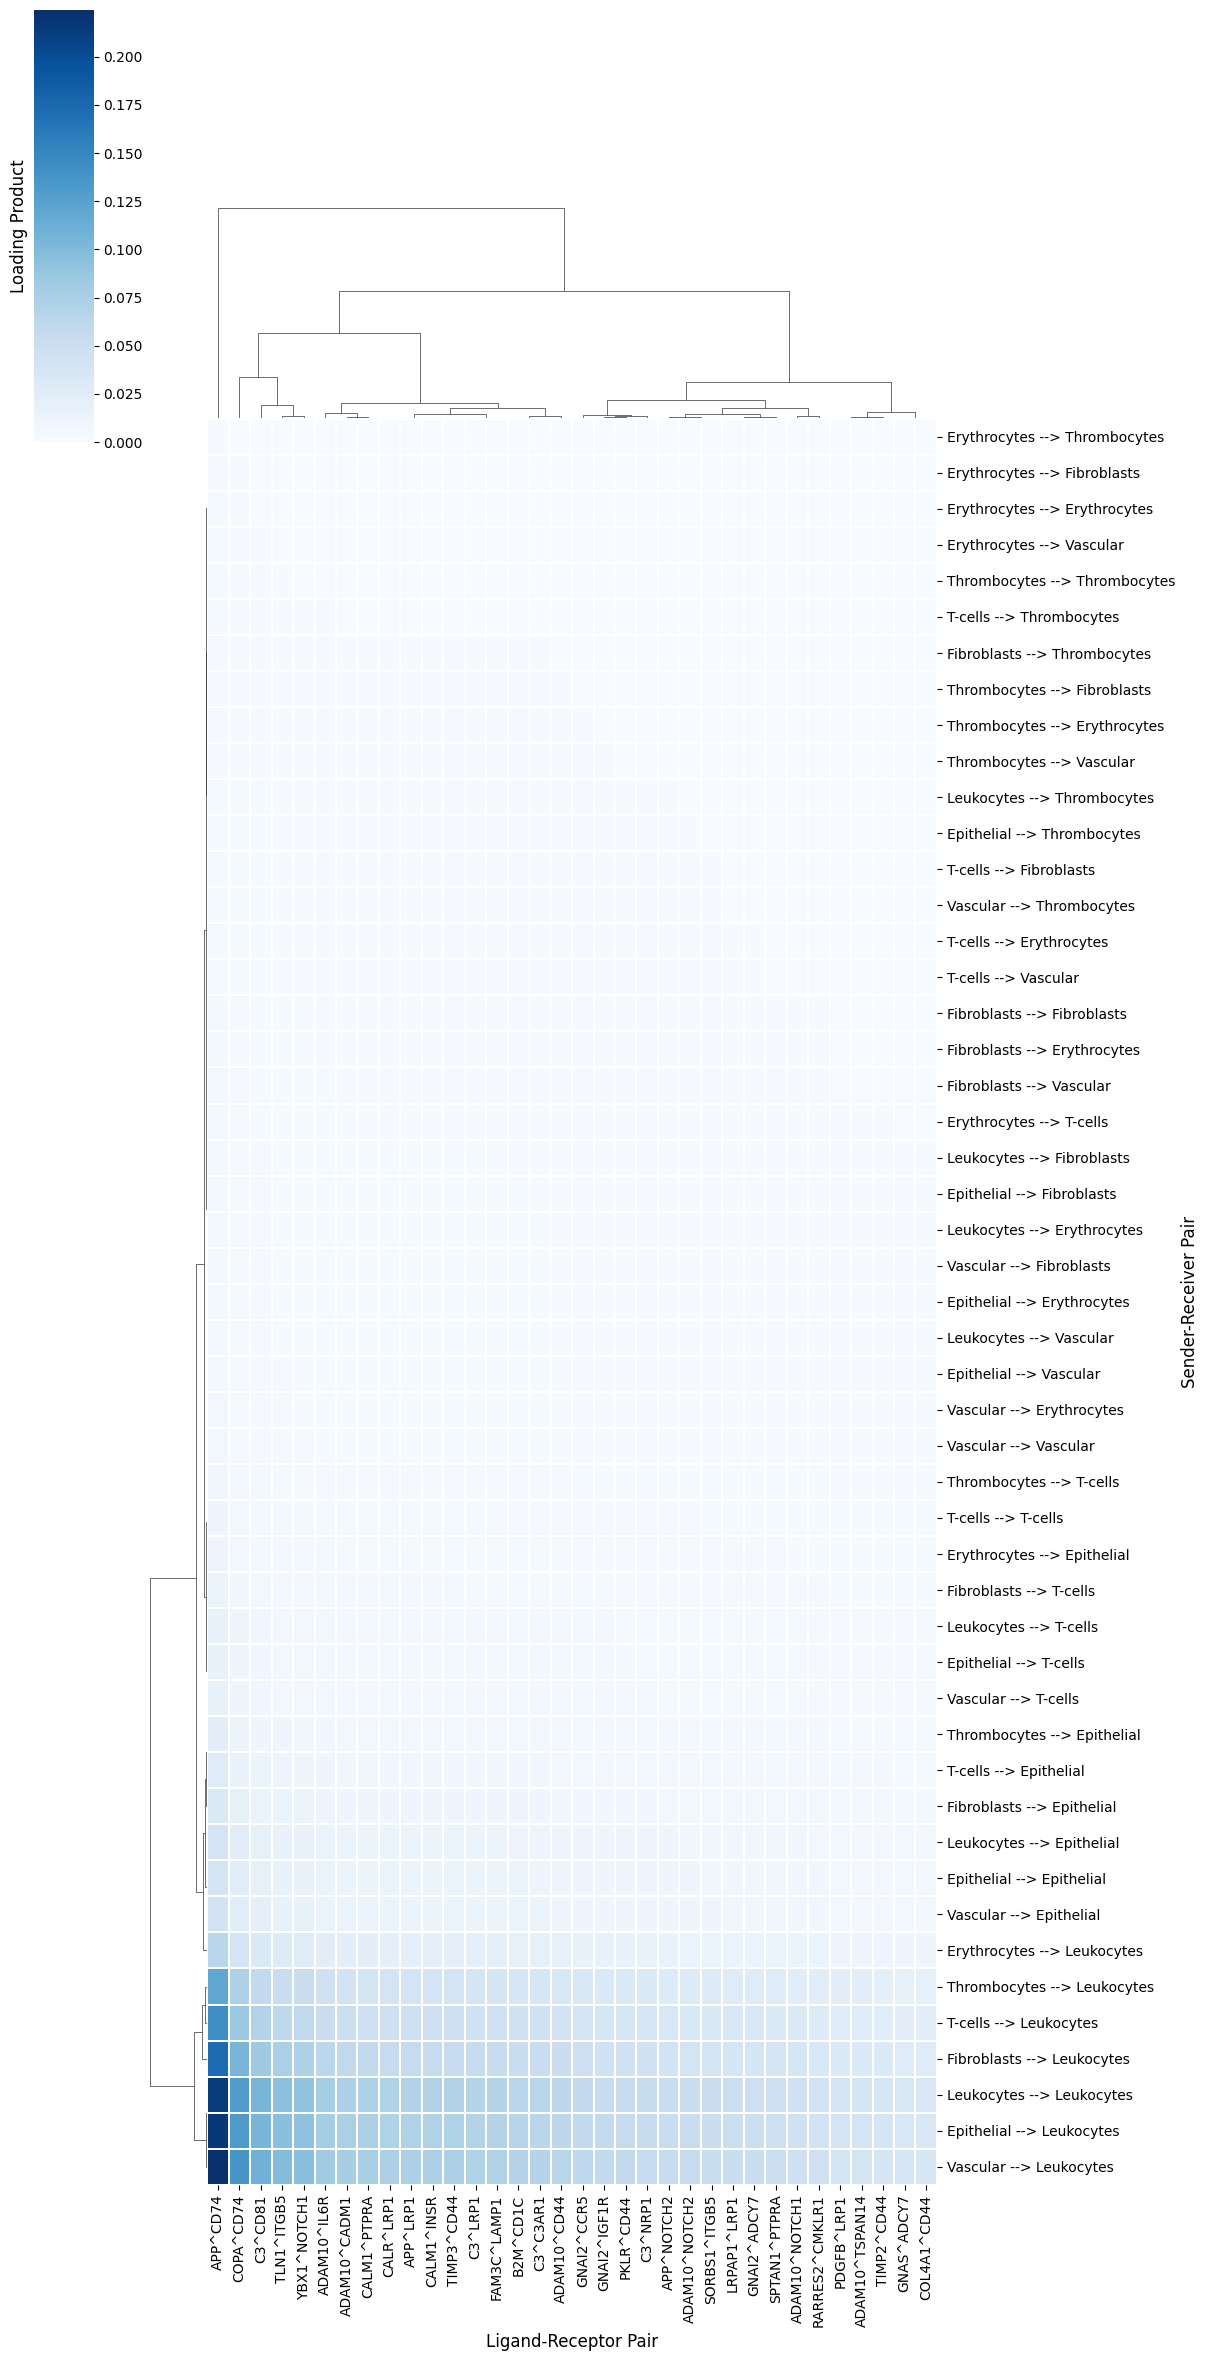

In [49]:
lr_cell_product = c2c.analysis.tensor_downstream.get_lr_by_cell_pairs(factors,
                                                                      lr_label='Ligand-Receptor Pairs',
                                                                      sender_label='Sender Cells',
                                                                      receiver_label='Receiver Cells',
                                                                      order_cells_by='receivers',
                                                                      factor=selected_factor,
                                                                      cci_threshold=None, # None for considering all cell-cell pairs.
                                                                      lr_threshold=0.075 # Prioritize important pairs. None for considering all of them
                                                                     )

lsr_prod_cm = c2c.plotting.loading_clustermap(lr_cell_product,
                                              use_zscore=False, # Whether standardizing the loadings across factors
                                              figsize=(12, 24),
                                              filename='figures/Clustermap-LR-CC-Pairs_factor_3.pdf',
                                              cbar_label='Loading Product',
                                              yticklabels=1
                                             )

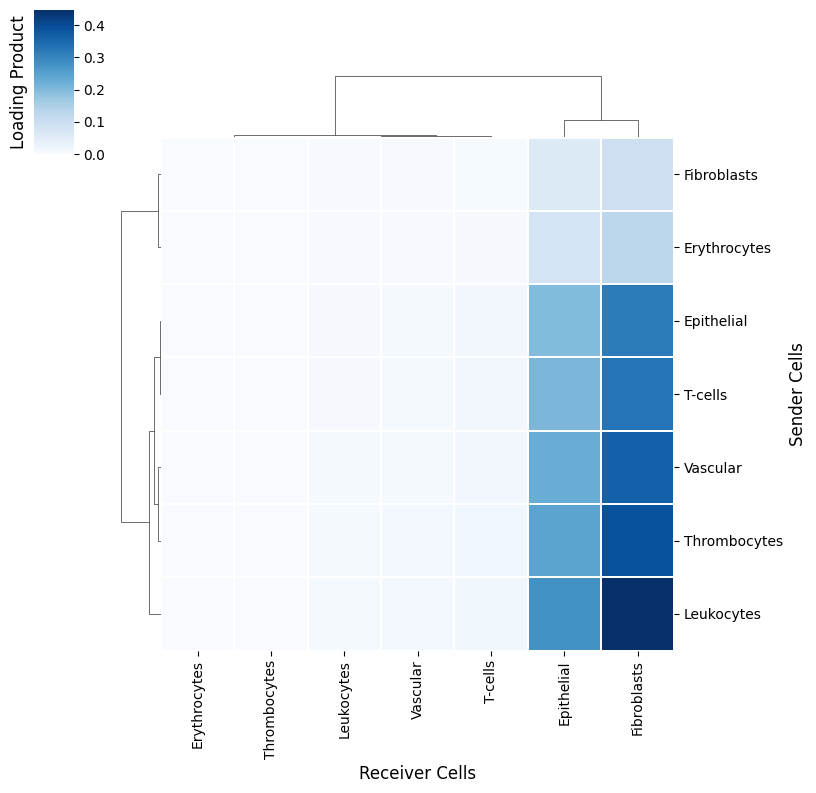

In [50]:
selected_factor = 'Factor 4'

loading_product = c2c.analysis.tensor_downstream.get_joint_loadings(factors,
                                                                    dim1='Sender Cells',
                                                                    dim2='Receiver Cells',
                                                                    factor=selected_factor,
                                                                   )

lprod_cm = c2c.plotting.loading_clustermap(loading_product.T, # Remove .T to transpose the axes
                                           use_zscore=False, # Whether standardizing the loadings across factors
                                           figsize=(8, 8),
                                           filename='figures/Clustermap-CC-Pairs_factor_4.pdf',
                                           cbar_label='Loading Product',
                                          )

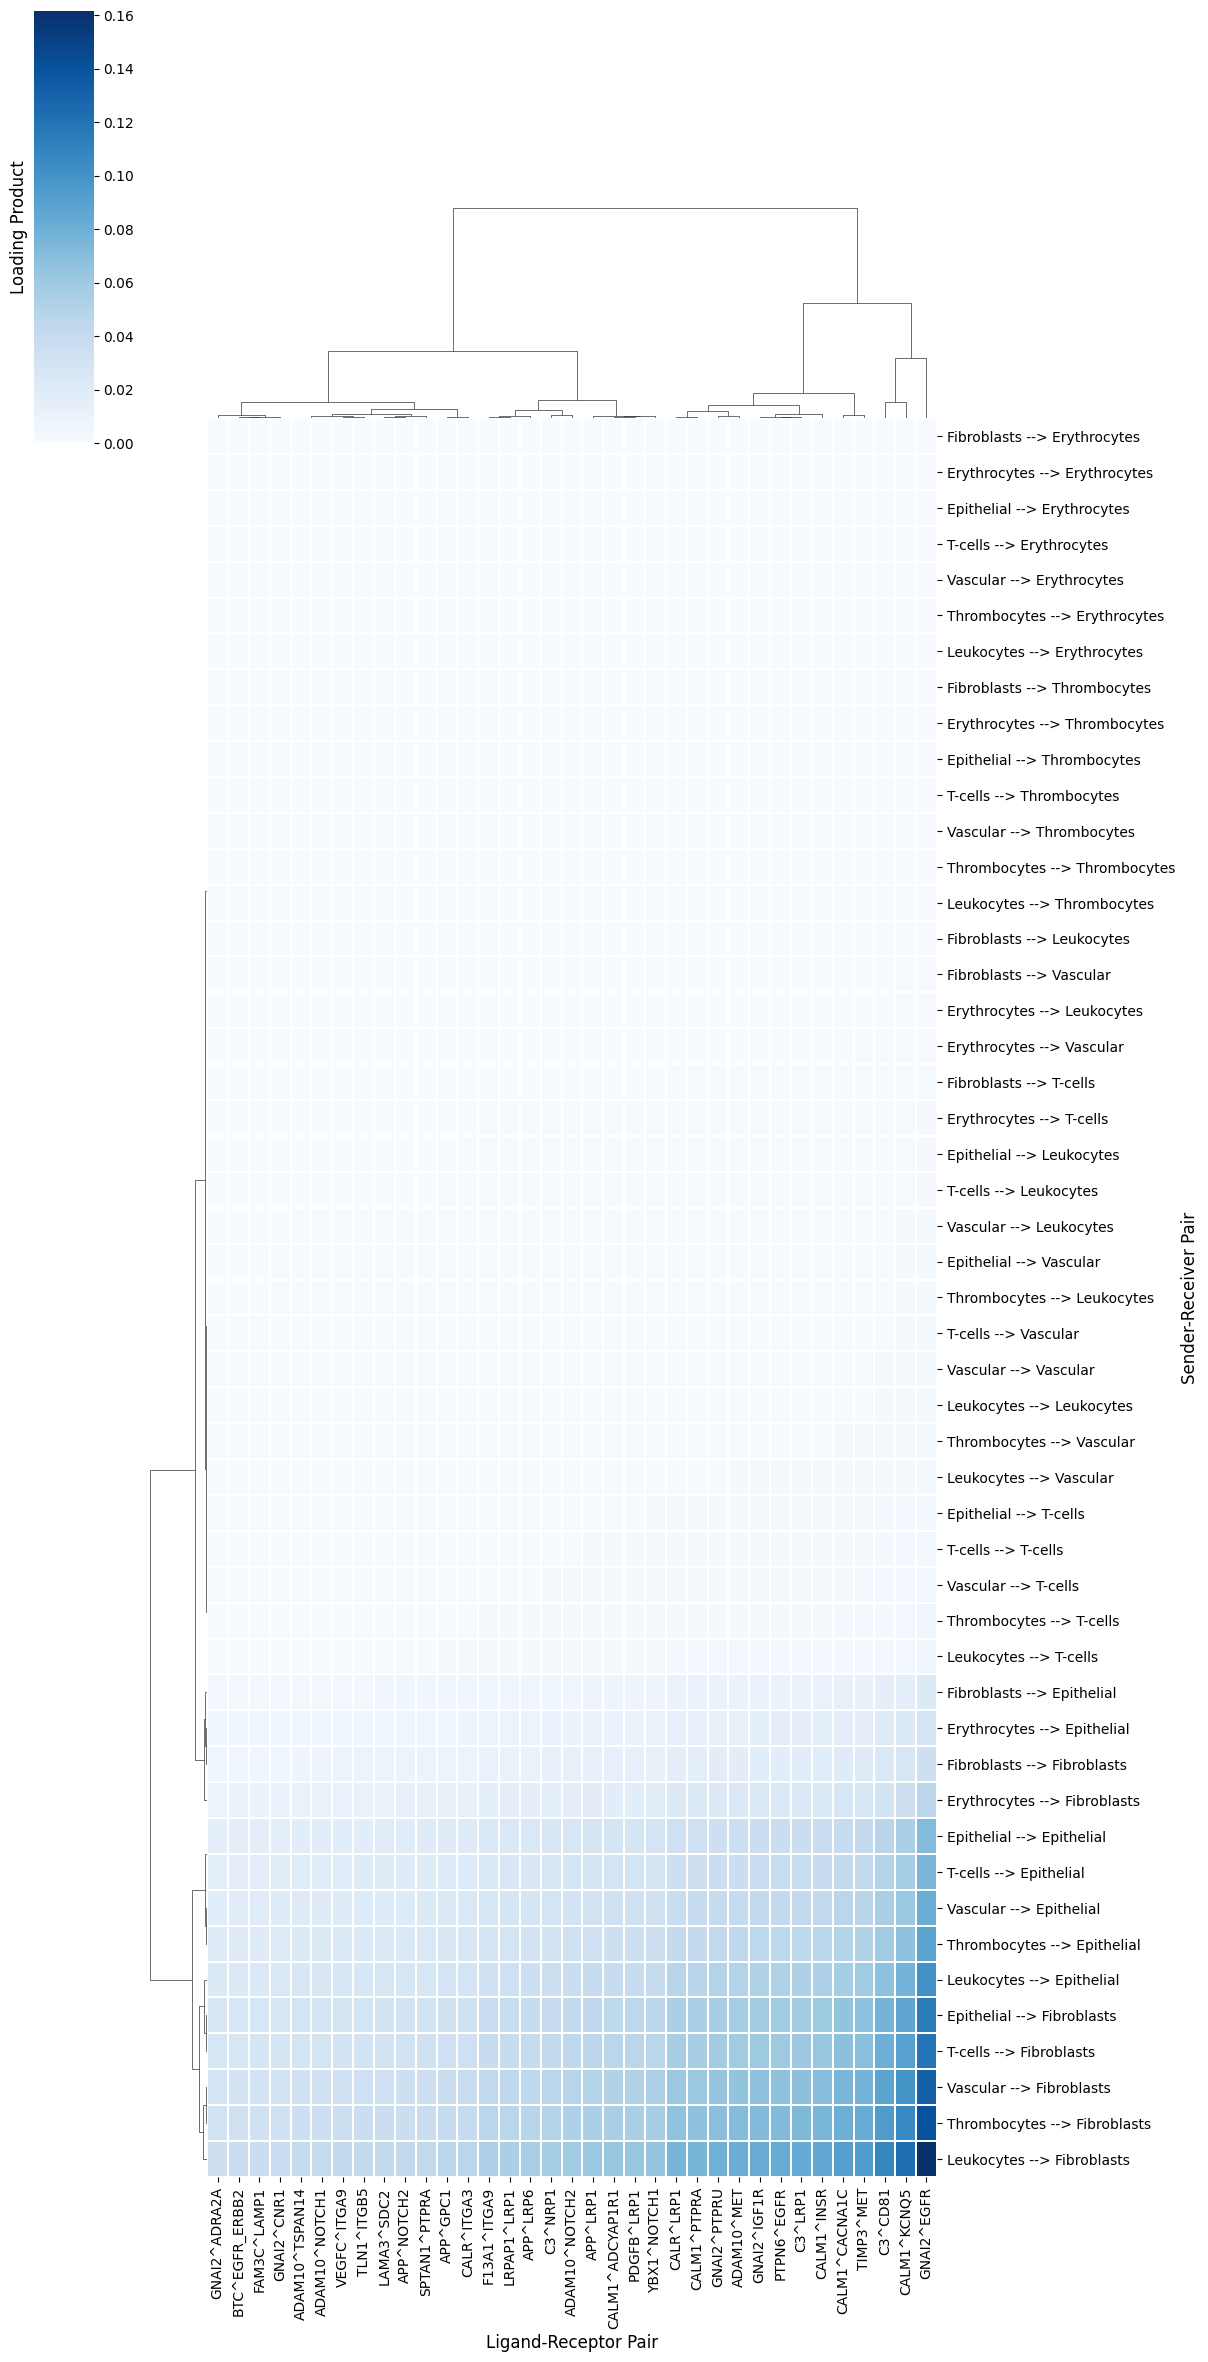

In [51]:
lr_cell_product = c2c.analysis.tensor_downstream.get_lr_by_cell_pairs(factors,
                                                                      lr_label='Ligand-Receptor Pairs',
                                                                      sender_label='Sender Cells',
                                                                      receiver_label='Receiver Cells',
                                                                      order_cells_by='receivers',
                                                                      factor=selected_factor,
                                                                      cci_threshold=None, # None for considering all cell-cell pairs.
                                                                      lr_threshold=0.075 # Prioritize important pairs. None for considering all of them
                                                                     )

lsr_prod_cm = c2c.plotting.loading_clustermap(lr_cell_product,
                                              use_zscore=False, # Whether standardizing the loadings across factors
                                              figsize=(12, 24),
                                              filename='figures/Clustermap-LR-CC-Pairs_factor_4.pdf',
                                              cbar_label='Loading Product',
                                              yticklabels=1
                                             )

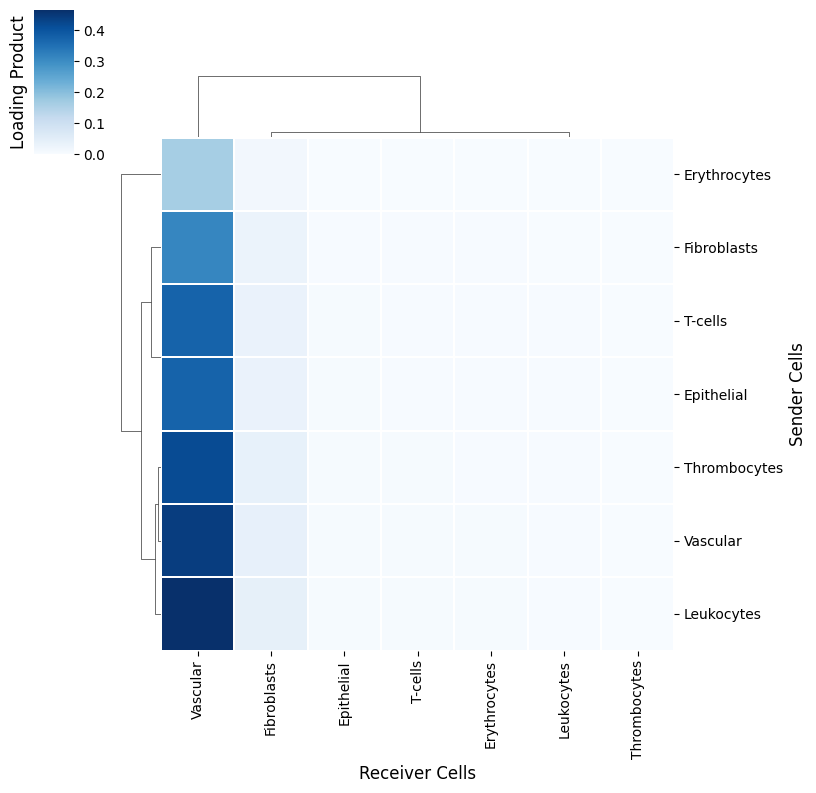

In [52]:
selected_factor = 'Factor 5'

loading_product = c2c.analysis.tensor_downstream.get_joint_loadings(factors,
                                                                    dim1='Sender Cells',
                                                                    dim2='Receiver Cells',
                                                                    factor=selected_factor,
                                                                   )

lprod_cm = c2c.plotting.loading_clustermap(loading_product.T, # Remove .T to transpose the axes
                                           use_zscore=False, # Whether standardizing the loadings across factors
                                           figsize=(8, 8),
                                           filename='figures/Clustermap-CC-Pairs_factor_5.pdf',
                                           cbar_label='Loading Product',
                                          )

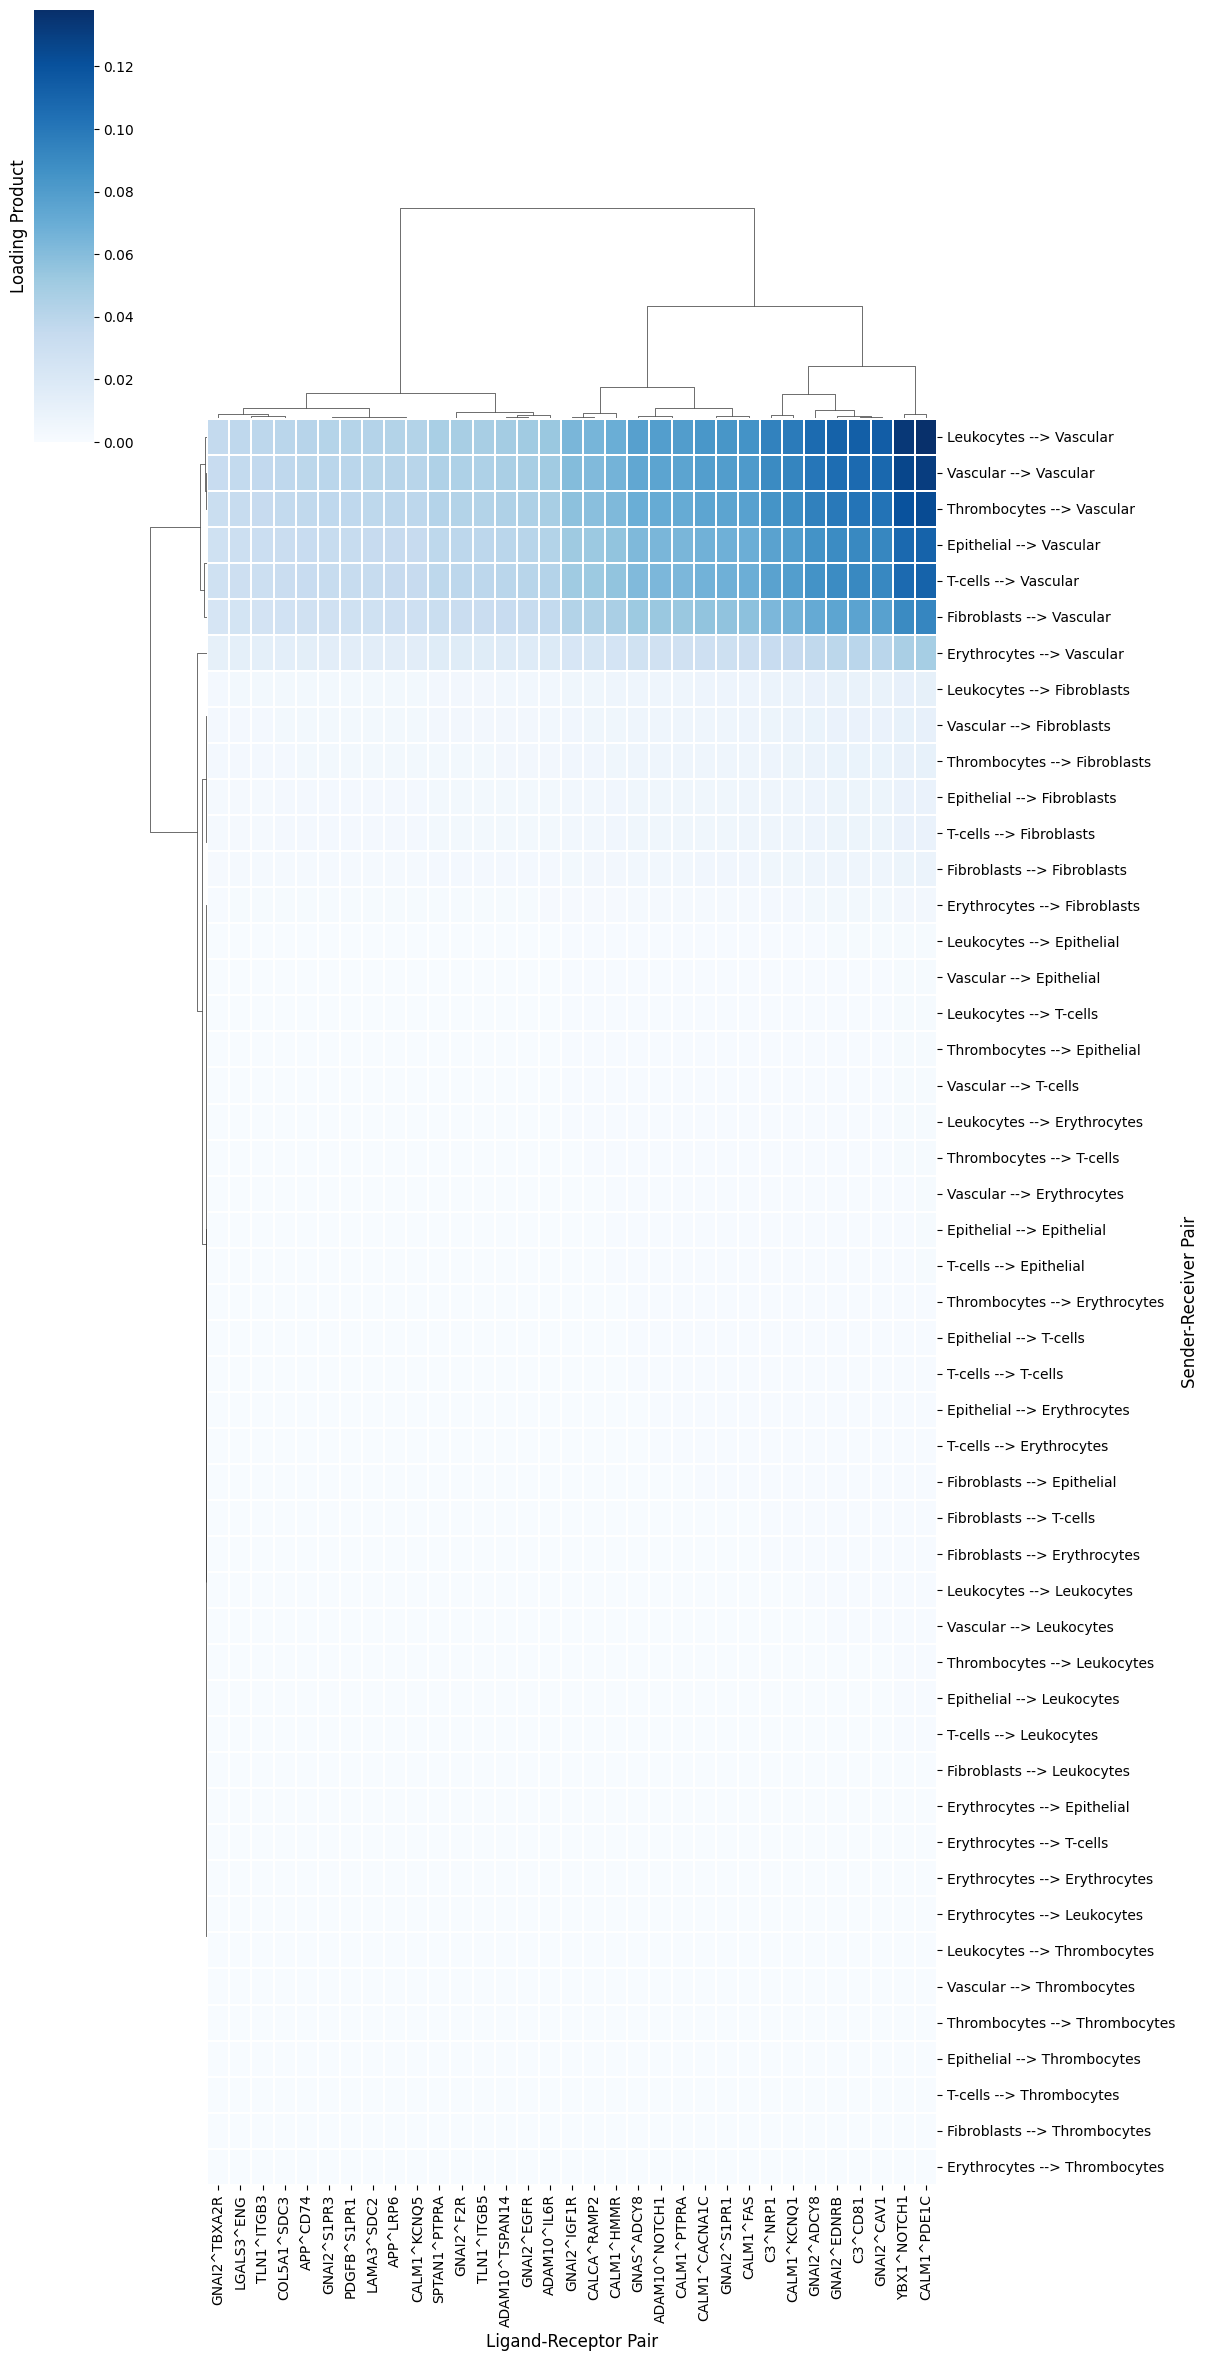

In [53]:
lr_cell_product = c2c.analysis.tensor_downstream.get_lr_by_cell_pairs(factors,
                                                                      lr_label='Ligand-Receptor Pairs',
                                                                      sender_label='Sender Cells',
                                                                      receiver_label='Receiver Cells',
                                                                      order_cells_by='receivers',
                                                                      factor=selected_factor,
                                                                      cci_threshold=None, # None for considering all cell-cell pairs.
                                                                      lr_threshold=0.075 # Prioritize important pairs. None for considering all of them
                                                                     )

lsr_prod_cm = c2c.plotting.loading_clustermap(lr_cell_product,
                                              use_zscore=False, # Whether standardizing the loadings across factors
                                              figsize=(12, 24),
                                              filename='figures/Clustermap-LR-CC-Pairs_factor_5.pdf',
                                              cbar_label='Loading Product',
                                              yticklabels=1
                                             )

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [55]:
#Get all outer products as adjacency matrices, one per factor
networks = c2c.analysis.tensor_downstream.get_factor_specific_ccc_networks(factors,
                                                                           sender_label='Sender Cells',
                                                                           receiver_label='Receiver Cells',
                                                                           )

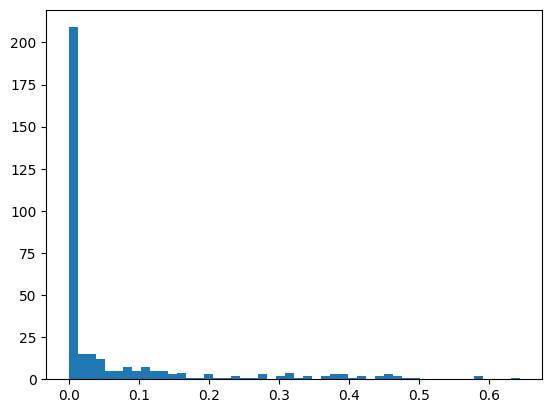

In [56]:
# Then, flatten the adjacency matrices
network_by_factors = c2c.analysis.tensor_downstream.flatten_factor_ccc_networks(networks, orderby='receivers')

# And we can plot the distributions of the weights for each factor-specific network
_ = plt.hist(network_by_factors.values.flatten(), bins = 50)

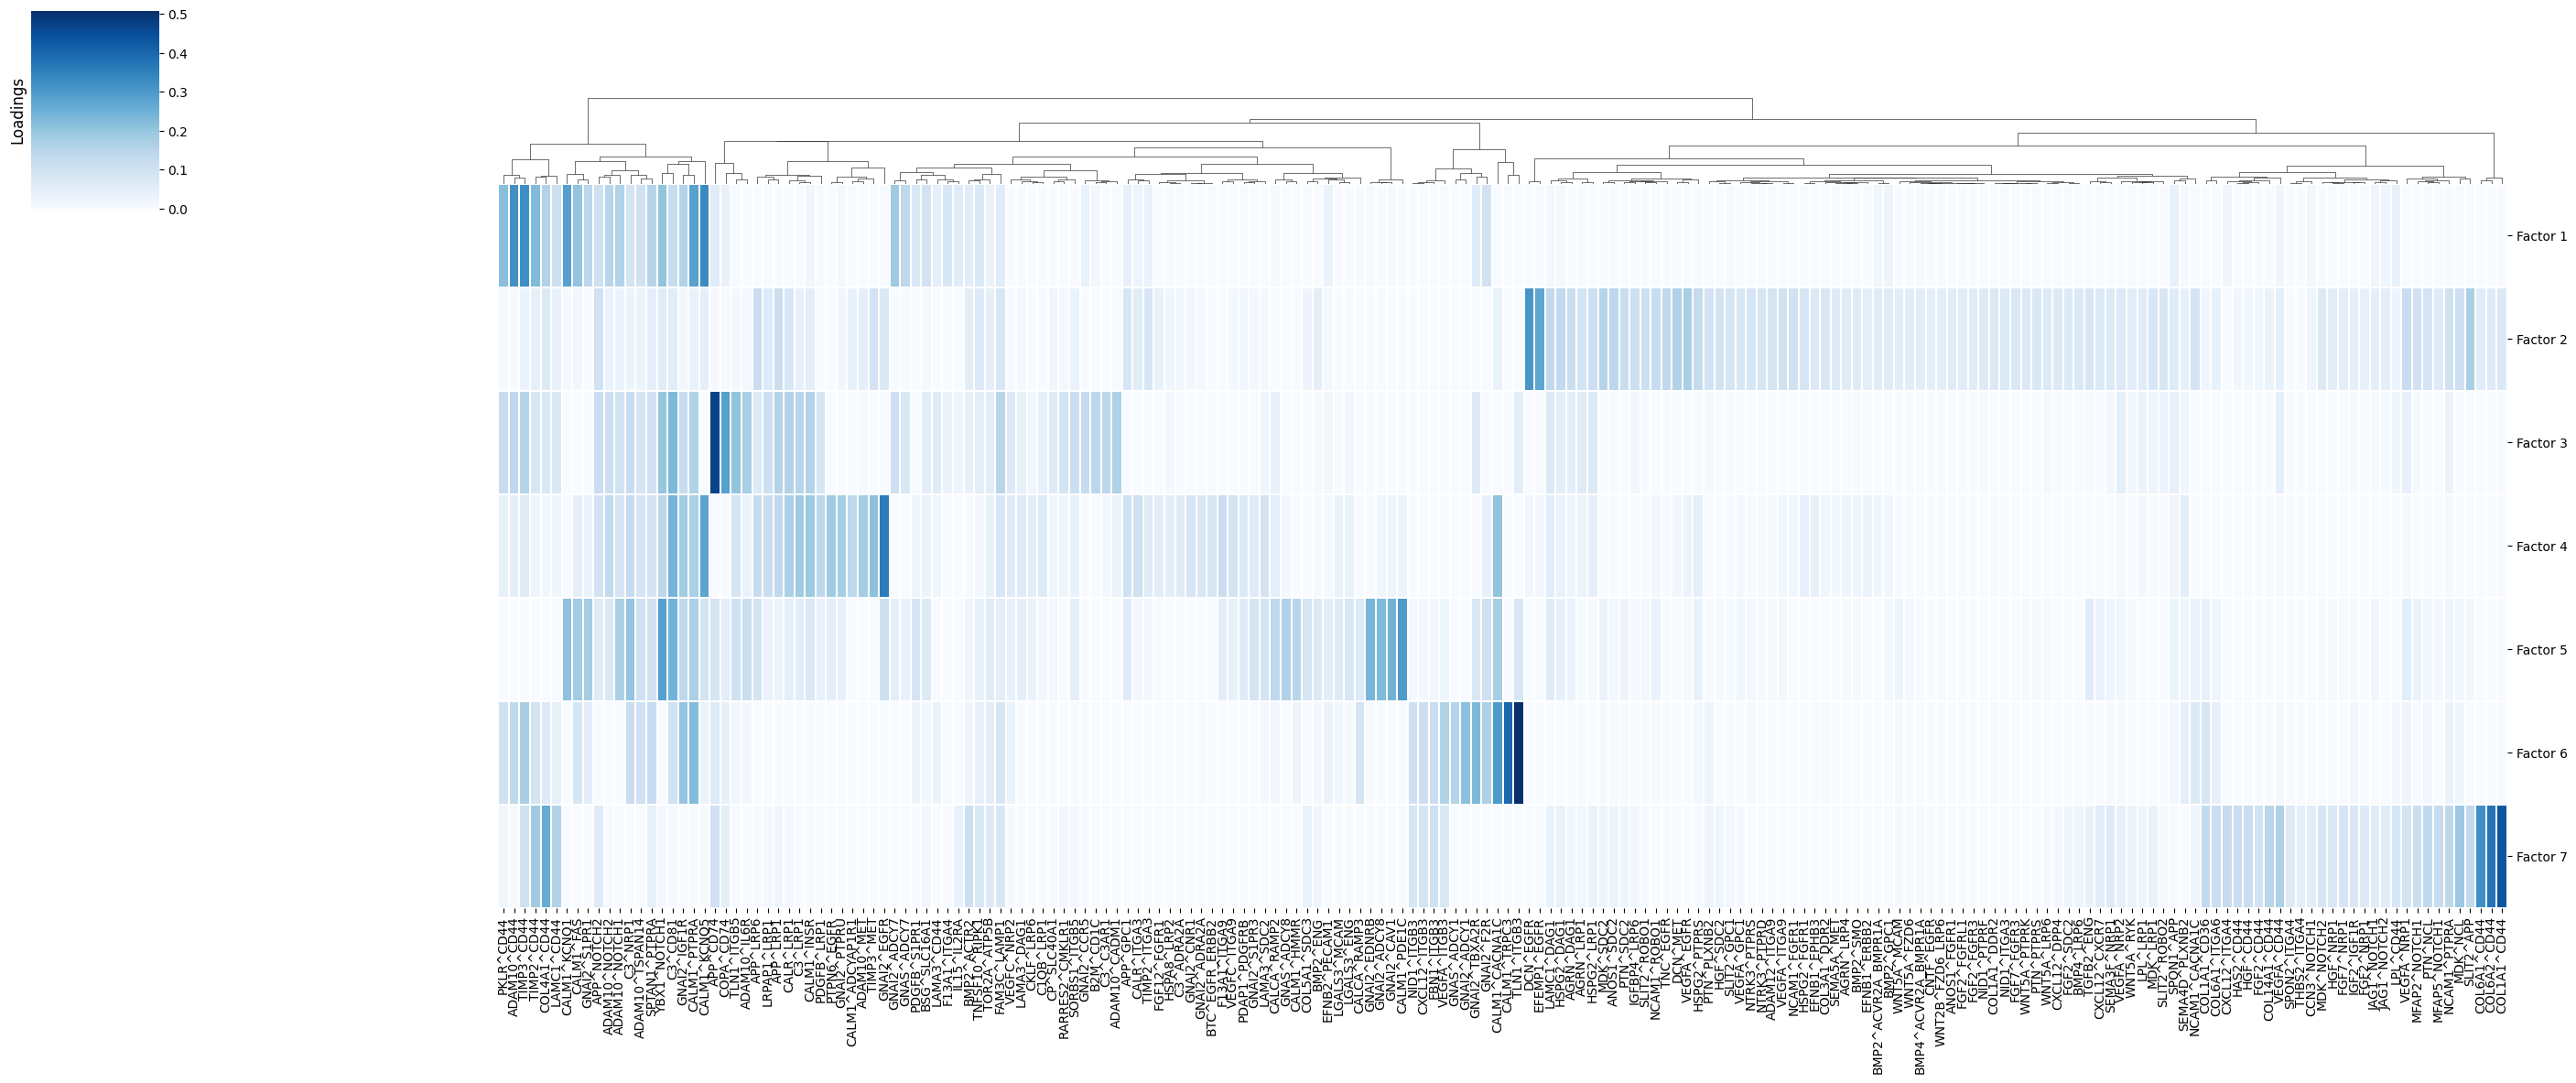

In [57]:
lr_cm = c2c.plotting.loading_clustermap(factors['Ligand-Receptor Pairs'],
                                        loading_threshold=0.05, # To consider only top LRs
                                        use_zscore=False, # Whether standardizing the loadings across factors
                                        figsize=(28, 12),
                                        filename='figures/Clustermap-LRs.pdf',
                                        row_cluster=False # To avoid clustering of factors
                                       )

In [58]:
selected_factor = 'Factor 1'

dc.plot_barplot(estimate,
                selected_factor,
                vertical=True,
                cmap='coolwarm')

AttributeError: module 'decoupler' has no attribute 'plot_barplot'